# Проектная работа
# "*Статистический анализ данных*"

### Описание проекта

**Заказчик исследования**: Сервис аренды самокатов GoFast.

**Цель исследования**:
1. Проанализировать данные о выборочных пользователях из нескольких городов, а также об их поездках;
2. Проверить некоторые гипотезы, которые могут помочь бизнесу вырасти;
3. Поработать с распределениями.

**Ход исследования**:

Данные для предстоящего анализа получим из файлов:
- `users_go.csv`- хранит информацию о пользователях;
- `rides_go.csv`- хранит информацию о поездках;
- `subscriptions_go.csv` - хранит информацию о подписках в мобильном приложении. 

О качестве данных ничего не известно. Поэтому перед анализом понадобится их обзор с целью выявления ошибок и оценки их влияния на предстоящее исследование. 

В предобработке будет проведена работа по исправлению найденных ошибок, добавлены новые столбцы. 

Далее проведем исследовательский анализ данных с описанием и визуализацией общей информации об основных параметрах исследования, осуществим объединение данных, подсчитаем выручку, проверим несколько гипотез и поработаем с распределениями. 

На основании полученных данных сделаем выводы и сформулируем краткие рекомендации.

***Примечание***

Чтобы совершать поездки по городу, пользователи сервиса GoFast пользуются мобильным приложением. **Сервисом можно пользоваться**:
- `без подписки`
    - абонентская плата отсутствует;
    - стоимость одной минуты поездки — 8 рублей;
    - стоимость старта (начала поездки) — 50 рублей;
- `с подпиской Ultra`
    - абонентская плата — 199 рублей в месяц;
    - стоимость одной минуты поездки — 6 рублей;
    - стоимость старта — бесплатно.
2. Данные получены из файлов:
- `users_go.csv`- хранит информацию о пользователях;
- `rides_go.csv`- хранит информацию о поездках;
- `subscriptions_go.csv` - хранит информацию о подписках в мобильном приложении. 
3. О качестве данных ничего не известно. Поэтому перед анализом понадобится их обзор

**Описание данных**

- `user_id` - уникальный идентификатор пользователя
- `name` -	имя пользователя
- `age`	- возраст
- `city` -	город
- `subscription_type` - тип подписки (free, ultra)
- `distance` -	расстояние, которое пользователь проехал в текущей сессии (в метрах)
- `duration` -	продолжительность сессии (в минутах) — время с того момента, как пользователь нажал кнопку «Начать поездку» до момента, как он нажал кнопку «Завершить поездку»
- `date` -	дата совершения поездки
- `subscription_type` - тип подписки
- `minute_price` - стоимость одной минуты поездки по данной подписке
- `start_ride_price` - стоимость начала поездки
- `subscription_fee` - стоимость ежемесячного платежа

Таким образом, **исследование пройдёт в восемь этапов** - в конце сделаю:

1. [Загрузка и обзор данных](#data)
2. [Предобработка данных](#data_preprocessing)
3. [Исследовательский анализ данных](#data_analysis)
4. [Объединение данных](#data_merging)
4. [Подсчет выручки](#revenue_calculation)
5. [Проверка гипотез](#hypothesis_testing)
6. [Распределения](#distributions)
7. [Формирование общего вывода](#conclusion)

<h1>Оглавление:<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"><li><span><a href="#Описание-проекта" data-toc-modified-id="Описание-проекта-1"><span class="toc-item-num">1&nbsp;&nbsp;</span>Описание проекта</a></span></li><li><span><a href="#Загрузка-и-обзор-данных" data-toc-modified-id="Загрузка-и-обзор-данных-2"><span class="toc-item-num">2&nbsp;&nbsp;</span>Загрузка и обзор данных</a></span></li><li><span><a href="#Предобработка-данных" data-toc-modified-id="Предобработка-данных-3"><span class="toc-item-num">3&nbsp;&nbsp;</span>Предобработка данных</a></span><ul class="toc-item"><li><span><a href="#Приведение-столбца-date-к-типу-даты-datetime" data-toc-modified-id="Приведение-столбца-date-к-типу-даты-datetime-3.1"><span class="toc-item-num">3.1&nbsp;&nbsp;</span>Приведение столбца <code>date</code> к типу даты <code>datetime</code></a></span></li><li><span><a href="#Создание-нового-столбца-с-номером-месяца-на-основе-столбца-date" data-toc-modified-id="Создание-нового-столбца-с-номером-месяца-на-основе-столбца-date-3.2"><span class="toc-item-num">3.2&nbsp;&nbsp;</span>Создание нового столбца с номером месяца на основе столбца <code>date</code></a></span></li><li><span><a href="#Проверка-на-наличие-пропущенных-значений-и-дубликатов-в-датафреймах.-Их-обработка,-если-такие-значения-присутствуют" data-toc-modified-id="Проверка-на-наличие-пропущенных-значений-и-дубликатов-в-датафреймах.-Их-обработка,-если-такие-значения-присутствуют-3.3"><span class="toc-item-num">3.3&nbsp;&nbsp;</span>Проверка на наличие пропущенных значений и дубликатов в датафреймах. Их обработка, если такие значения присутствуют</a></span></li></ul></li><li><span><a href="#Исследовательский-анализ-данных" data-toc-modified-id="Исследовательский-анализ-данных-4"><span class="toc-item-num">4&nbsp;&nbsp;</span>Исследовательский анализ данных</a></span><ul class="toc-item"><li><span><a href="#Опиcание-и-визуализация-общей-информации-о-частоте-встречаемости-городов" data-toc-modified-id="Опиcание-и-визуализация-общей-информации-о-частоте-встречаемости-городов-4.1"><span class="toc-item-num">4.1&nbsp;&nbsp;</span>Опиcание и визуализация общей информации о частоте встречаемости городов</a></span></li><li><span><a href="#Опиcание-и-визуализация-общей-информации-о-соотношении-пользователей-с-подпиской-и-без-подписки" data-toc-modified-id="Опиcание-и-визуализация-общей-информации-о-соотношении-пользователей-с-подпиской-и-без-подписки-4.2"><span class="toc-item-num">4.2&nbsp;&nbsp;</span>Опиcание и визуализация общей информации о соотношении пользователей с подпиской и без подписки</a></span></li><li><span><a href="#Опиcание-и-визуализация-общей-информации-о-возрасте-пользователей" data-toc-modified-id="Опиcание-и-визуализация-общей-информации-о-возрасте-пользователей-4.3"><span class="toc-item-num">4.3&nbsp;&nbsp;</span>Опиcание и визуализация общей информации о возрасте пользователей</a></span></li><li><span><a href="#Опиcание-и-визуализация-общей-информации-о--расстоянии,-которое-пользователь-преодолел-за-одну-поездку" data-toc-modified-id="Опиcание-и-визуализация-общей-информации-о--расстоянии,-которое-пользователь-преодолел-за-одну-поездку-4.4"><span class="toc-item-num">4.4&nbsp;&nbsp;</span>Опиcание и визуализация общей информации о  расстоянии, которое пользователь преодолел за одну поездку</a></span></li><li><span><a href="#Опиcание-и-визуализация-общей-информации-о--продолжительности-поездок" data-toc-modified-id="Опиcание-и-визуализация-общей-информации-о--продолжительности-поездок-4.5"><span class="toc-item-num">4.5&nbsp;&nbsp;</span>Опиcание и визуализация общей информации о  продолжительности поездок</a></span></li><li><span><a href="#Обобщенный-вывод-по-п.4" data-toc-modified-id="Обобщенный-вывод-по-п.4-4.6"><span class="toc-item-num">4.6&nbsp;&nbsp;</span>Обобщенный вывод по п.4</a></span></li></ul></li><li><span><a href="#Объединение-данных" data-toc-modified-id="Объединение-данных-5"><span class="toc-item-num">5&nbsp;&nbsp;</span>Объединение данных</a></span><ul class="toc-item"><li><span><a href="#Объединение-данных-о-пользователях,-поездках-и-подписках-в-один-датафрейм" data-toc-modified-id="Объединение-данных-о-пользователях,-поездках-и-подписках-в-один-датафрейм-5.1"><span class="toc-item-num">5.1&nbsp;&nbsp;</span>Объединение данных о пользователях, поездках и подписках в один датафрейм</a></span></li><li><span><a href="#Создание--из-датафрейма,-созданного-на-этапе-5.1,-ещё-двух-датафреймов:-c-данными-о-пользователях-без-подписки-и-с-данными-о-пользователях-с-подпиской" data-toc-modified-id="Создание--из-датафрейма,-созданного-на-этапе-5.1,-ещё-двух-датафреймов:-c-данными-о-пользователях-без-подписки-и-с-данными-о-пользователях-с-подпиской-5.2"><span class="toc-item-num">5.2&nbsp;&nbsp;</span>Создание  из датафрейма, созданного на этапе 5.1, ещё двух датафреймов: c данными о пользователях без подписки и с данными о пользователях с подпиской</a></span><ul class="toc-item"><li><span><a href="#Создание--датафрейма-из-датафрейма-gofast_merged_data--c-данными-о-пользователях-без-подписки" data-toc-modified-id="Создание--датафрейма-из-датафрейма-gofast_merged_data--c-данными-о-пользователях-без-подписки-5.2.1"><span class="toc-item-num">5.2.1&nbsp;&nbsp;</span>Создание  датафрейма из датафрейма <code>gofast_merged_data</code>  c данными о пользователях без подписки</a></span></li><li><span><a href="#Создание--датафрейма-из-датафрейма-gofast_merged_data--c-данными-о-пользователях-с-подпиской" data-toc-modified-id="Создание--датафрейма-из-датафрейма-gofast_merged_data--c-данными-о-пользователях-с-подпиской-5.2.2"><span class="toc-item-num">5.2.2&nbsp;&nbsp;</span>Создание  датафрейма из датафрейма <code>gofast_merged_data</code>  c данными о пользователях с подпиской</a></span></li></ul></li><li><span><a href="#Визуализация-информации-о-расстоянии-и-времени-поездок-для-пользователей-обеих-категорий" data-toc-modified-id="Визуализация-информации-о-расстоянии-и-времени-поездок-для-пользователей-обеих-категорий-5.3"><span class="toc-item-num">5.3&nbsp;&nbsp;</span>Визуализация информации о расстоянии и времени поездок для пользователей обеих категорий</a></span></li></ul></li><li><span><a href="#Подсчёт-выручки" data-toc-modified-id="Подсчёт-выручки-6"><span class="toc-item-num">6&nbsp;&nbsp;</span>Подсчёт выручки</a></span><ul class="toc-item"><li><span><a href="#Создание-датафрейма-с-агрегированными-данными-о-поездках-на-основе-датафрейма-с-объединёнными-данными-из-шага-5:-поиск-суммарного-расстояния,-количества-поездок-и-суммарного-времени-для-каждого-пользователя-за-каждый-месяц" data-toc-modified-id="Создание-датафрейма-с-агрегированными-данными-о-поездках-на-основе-датафрейма-с-объединёнными-данными-из-шага-5:-поиск-суммарного-расстояния,-количества-поездок-и-суммарного-времени-для-каждого-пользователя-за-каждый-месяц-6.1"><span class="toc-item-num">6.1&nbsp;&nbsp;</span>Создание датафрейма с агрегированными данными о поездках на основе датафрейма с объединёнными данными из шага 5: поиск суммарного расстояния, количества поездок и суммарного времени для каждого пользователя за каждый месяц</a></span></li><li><span><a href="#Добавление-в-датафрейм-aggregated_data-столбца-с-помесячной-выручкой,-которую-принёс-каждый-пользователь" data-toc-modified-id="Добавление-в-датафрейм-aggregated_data-столбца-с-помесячной-выручкой,-которую-принёс-каждый-пользователь-6.2"><span class="toc-item-num">6.2&nbsp;&nbsp;</span>Добавление в датафрейм <code>aggregated_data</code> столбца с помесячной выручкой, которую принёс каждый пользователь</a></span></li></ul></li><li><span><a href="#Проверка-гипотез" data-toc-modified-id="Проверка-гипотез-7"><span class="toc-item-num">7&nbsp;&nbsp;</span>Проверка гипотез</a></span><ul class="toc-item"><li><span><a href="#Проверка-гипотезы:-тратят-ли-пользователи-с-подпиской-больше-времени-на-поездки?" data-toc-modified-id="Проверка-гипотезы:-тратят-ли-пользователи-с-подпиской-больше-времени-на-поездки?-7.1"><span class="toc-item-num">7.1&nbsp;&nbsp;</span>Проверка гипотезы: тратят ли пользователи с подпиской больше времени на поездки?</a></span></li><li><span><a href="#Проверка-гипотезы:-среднее-расстояние,-которое-проезжают-пользователи-с-подпиской-за-одну-поездку,-не-превышает-3130-метров" data-toc-modified-id="Проверка-гипотезы:-среднее-расстояние,-которое-проезжают-пользователи-с-подпиской-за-одну-поездку,-не-превышает-3130-метров-7.2"><span class="toc-item-num">7.2&nbsp;&nbsp;</span>Проверка гипотезы: среднее расстояние, которое проезжают пользователи с подпиской за одну поездку, не превышает 3130 метров</a></span></li><li><span><a href="#Проверка-гипотезы:-будет-ли-помесячная-выручка-от-пользователей-с-подпиской-по-месяцам-выше,-чем-выручка-от-пользователей-без-подписки" data-toc-modified-id="Проверка-гипотезы:-будет-ли-помесячная-выручка-от-пользователей-с-подпиской-по-месяцам-выше,-чем-выручка-от-пользователей-без-подписки-7.3"><span class="toc-item-num">7.3&nbsp;&nbsp;</span>Проверка гипотезы: будет ли помесячная выручка от пользователей с подпиской по месяцам выше, чем выручка от пользователей без подписки</a></span></li><li><span><a href="#Ответ-на-вопрос:-Какой-тест-понадобился-бы-для-проверки-гипотезы?" data-toc-modified-id="Ответ-на-вопрос:-Какой-тест-понадобился-бы-для-проверки-гипотезы?-7.4"><span class="toc-item-num">7.4&nbsp;&nbsp;</span>Ответ на вопрос: Какой тест понадобился бы для проверки гипотезы?</a></span></li><li><span><a href="#Обобщенный-вывод-по-п.7" data-toc-modified-id="Обобщенный-вывод-по-п.7-7.5"><span class="toc-item-num">7.5&nbsp;&nbsp;</span>Обобщенный вывод по п.7</a></span></li></ul></li><li><span><a href="#Распределения-(необязательное-задание)" data-toc-modified-id="Распределения-(необязательное-задание)-8"><span class="toc-item-num">8&nbsp;&nbsp;</span>Распределения (необязательное задание)</a></span><ul class="toc-item"><li><span><a href="#Определение-минимального-количества-промокодов,-которое-нужно-разослать,-чтобы-вероятность-не-выполнить-план-была-примерно-5-%" data-toc-modified-id="Определение-минимального-количества-промокодов,-которое-нужно-разослать,-чтобы-вероятность-не-выполнить-план-была-примерно-5-%-8.1"><span class="toc-item-num">8.1&nbsp;&nbsp;</span>Определение минимального количества промокодов, которое нужно разослать, чтобы вероятность не выполнить план была примерно 5 %</a></span></li><li><span><a href="#Построение-с-помощью-аппроксимации-примерного-графика-распределения-и-оценка-вероятности-того,-что-уведомление-откроют-не-более-399,5-тыс.-пользователей" data-toc-modified-id="Построение-с-помощью-аппроксимации-примерного-графика-распределения-и-оценка-вероятности-того,-что-уведомление-откроют-не-более-399,5-тыс.-пользователей-8.2"><span class="toc-item-num">8.2&nbsp;&nbsp;</span>Построение с помощью аппроксимации примерного графика распределения и оценка вероятности того, что уведомление откроют не более 399,5 тыс. пользователей</a></span></li></ul></li><li><span><a href="#Общий-вывод:" data-toc-modified-id="Общий-вывод:-9"><span class="toc-item-num">9&nbsp;&nbsp;</span>Общий вывод:</a></span><ul class="toc-item"><li><span><a href="#Обзор-и-обработка-данных:" data-toc-modified-id="Обзор-и-обработка-данных:-9.1"><span class="toc-item-num">9.1&nbsp;&nbsp;</span>Обзор и обработка данных:</a></span></li><li><span><a href="#Предобработка-данных:" data-toc-modified-id="Предобработка-данных:-9.2"><span class="toc-item-num">9.2&nbsp;&nbsp;</span>Предобработка данных:</a></span></li><li><span><a href="#Исследовательский-анализ-данных:" data-toc-modified-id="Исследовательский-анализ-данных:-9.3"><span class="toc-item-num">9.3&nbsp;&nbsp;</span>Исследовательский анализ данных:</a></span></li><li><span><a href="#Объединение-данных" data-toc-modified-id="Объединение-данных-9.4"><span class="toc-item-num">9.4&nbsp;&nbsp;</span>Объединение данных</a></span></li><li><span><a href="#Подсчет-выручки" data-toc-modified-id="Подсчет-выручки-9.5"><span class="toc-item-num">9.5&nbsp;&nbsp;</span>Подсчет выручки</a></span></li><li><span><a href="#Проверка-гипотез" data-toc-modified-id="Проверка-гипотез-9.6"><span class="toc-item-num">9.6&nbsp;&nbsp;</span>Проверка гипотез</a></span></li><li><span><a href="#Распределения" data-toc-modified-id="Распределения-9.7"><span class="toc-item-num">9.7&nbsp;&nbsp;</span>Распределения</a></span></li></ul></li><li><span><a href="#Рекомендации-по-развитию-аренды-самокатов" data-toc-modified-id="Рекомендации-по-развитию-аренды-самокатов-10"><span class="toc-item-num">10&nbsp;&nbsp;</span>Рекомендации по развитию аренды самокатов</a></span></li></ul></div>

### Загрузка и обзор данных

**Импортируем основные библиотеки, которые понадобятся нам в дальнейшем. Считаем данные из csv-файлов в датафреймы и сохраним в переменные.**  
<a id='data'></a>
**Пути к файлам**

- пользователи: `/datasets/users_go.csv`. [Скачать датасет](https://code.s3.yandex.net/datasets/users_go.csv);
- поездки: `/datasets/rides_go.csv`. [Скачать датасет](https://code.s3.yandex.net/datasets/rides_go.csv);
- подписки: `/datasets/subscriptions_go.csv`. [Скачать датасет](https://code.s3.yandex.net/datasets/subscriptions_go.csv).

In [1]:
import pandas as pd
from datetime import datetime, timedelta  # функции для работы со временем
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats as st
from scipy.stats import binom
from math import factorial
from math import sqrt

In [2]:
# Данные о пользователях сохраняем в переменную user_data
# Данные о поездках сохраняем в переменную scooter_ride_data
# Данные о подписках сохраняем в переменную subscriptions_data

try:
    user_data, scooter_ride_data,subscriptions_data  = (
        pd.read_csv('/datasets/users_go.csv'),
        pd.read_csv('/datasets/rides_go.csv'), 
        pd.read_csv('/datasets/subscriptions_go.csv')  
    )
except:
    user_data, scooter_ride_data,subscriptions_data = (
        pd.read_csv('C:/Users/Мария/Desktop/Практикум/Датасеты/Статистика_проект/users_go.csv'),
        pd.read_csv('C:/Users/Мария/Desktop/Практикум/Датасеты/Статистика_проект/rides_go.csv'),
        pd.read_csv('C:/Users/Мария/Desktop/Практикум/Датасеты/Статистика_проект/subscriptions_go.csv') 
    )           

Изучим данные и выполним предобработку. Проверим, есть ли в данных пропуски и дубликаты. Убедимся, что типы данных во всех колонках соответствуют сохранённым в них значениям.

**Для начала проведем первичный анализ всех трех датафреймов. Воспользуемся функцией `analyze_all_dfs`**


In [3]:
def analyze_all_dfs(user_data, scooter_ride_data,subscriptions_data):
    # Внутри функции создаем словарь dfs, где каждому датафрейму даем имя 
    dfs = {
        "user_data (данные о пользователях)": user_data,
        "scooter_ride_data (данные о поездках)": scooter_ride_data,
        "subscriptions_data (данные о подписках)": subscriptions_data
    }
    
    # Функция последовательно проходит по каждому датафрейму и выводит результаты анализа по стандартному набору операций:  
    for name, df in dfs.items():
        print(f"\n=== Первичный анализ датафрейма {name} ===")

        print("\n1. Общая информация:")
        print('*'*40)
        df.info()

        print("\n2. Анализ пропусков в данных:")
        print('*'*40)
        print(df.isna().sum())

        print("\n3. Вывод первых 5 строк:")
        print('*'*40)
        display(df.head())

        print("\n4. Статистика по числовым столбцам:")
        print('*'*40)
        display(df.describe())

        print("\n5. Проверка на дубликаты:")
        print('*'*40)
        print(f"Количество дубликатов: {df.duplicated().sum()}")

        print("\n6. Для анализа категориальных данных:")
        print('*'*40)
        for col in df.select_dtypes(include=['object', 'category']).columns:
            print(f"\n- {col} (Top 10 показателей):")
            display(df[col].value_counts().head(10))

        print("\n" + "="*50 + "\n")



analyze_all_dfs(user_data, scooter_ride_data,subscriptions_data)



=== Первичный анализ датафрейма user_data (данные о пользователях) ===

1. Общая информация:
****************************************
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1565 entries, 0 to 1564
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   user_id            1565 non-null   int64 
 1   name               1565 non-null   object
 2   age                1565 non-null   int64 
 3   city               1565 non-null   object
 4   subscription_type  1565 non-null   object
dtypes: int64(2), object(3)
memory usage: 61.3+ KB

2. Анализ пропусков в данных:
****************************************
user_id              0
name                 0
age                  0
city                 0
subscription_type    0
dtype: int64

3. Вывод первых 5 строк:
****************************************


,user_id,name,age,city,subscription_type
0,1,Кира,22,Тюмень,ultra
1,2,Станислав,31,Омск,ultra
2,3,Алексей,20,Москва,ultra
3,4,Константин,26,Ростов-на-Дону,ultra
4,5,Адель,28,Омск,ultra



4. Статистика по числовым столбцам:
****************************************


,user_id,age
count,1565.000000,1565.000000
mean,762.633866,24.922045
std,443.260155,4.553496
min,1.000000,12.000000
25%,378.000000,22.000000
50%,762.000000,25.000000
75%,1146.000000,28.000000
max,1534.000000,43.000000



5. Проверка на дубликаты:
****************************************
Количество дубликатов: 31

6. Для анализа категориальных данных:
****************************************

- name (Top 10 показателей):


...

,subscription_type,minute_price,start_ride_price,subscription_fee
0,free,8,50,0
1,ultra,6,0,199



4. Статистика по числовым столбцам:
****************************************


,minute_price,start_ride_price,subscription_fee
count,2.000000,2.000000,2.000000
mean,7.000000,25.000000,99.500000
std,1.414214,35.355339,140.714249
min,6.000000,0.000000,0.000000
25%,6.500000,12.500000,49.750000
50%,7.000000,25.000000,99.500000
75%,7.500000,37.500000,149.250000
max,8.000000,50.000000,199.000000



5. Проверка на дубликаты:
****************************************
Количество дубликатов: 0

6. Для анализа категориальных данных:
****************************************

- subscription_type (Top 10 показателей):


free     1
ultra    1
Name: subscription_type, dtype: int64

**Из полученной информации по всем трем датафреймам можно сделать следующий вывод**:
1. Датайфрейм `user_data (данные о пользователях)`:
- содержит 1565 строк и 5 столбцов;
- наименование столбцов соответствуют стилю `snake_case`;
- все указанные типы данных соответствуют данным, сожержащимся в столбцах;
- пропусков нет;
- минимальный возраст пользователя - 12 лет, максимальный - 43 года, медианный возраст пользователей - 25 лет;
- выявлено 31 явных дубликатов, нужно более детально изучить их;
- в топ городов по количеству пользователей вошли: Пятигорск, Екатеринбург, Ростов-на-Дону, Краснодар, Сочи;
- без подписки 846 пользователей, с подиской - 719 (подписку в мобильном приложении пользователи оформляют на 15% реже)
2. Датайфрейм `scooter_ride_data (данные о поездках)`:
- содержит 18068 строк и 4 столбца;
- наименование столбцов соответствуют стилю `snake_case`;
- столбец `date`, содержащий сведения о дате совершения поездки, имеет тип данных `object` - **нужно перевести его в формат `datetime`**;
- пропусков нет;
- минимальная дистанция - `0,86 метров`, минимальная продолжительность сессии - `0,5 минут`, максимальное расстояние, которое пользователь проехал за одну сессию - `7 211 метров`, максимальная продолжительность сессии - `40,8 минут`;
- явнях дубликатов не выявлено;
- больше всего поездок совершено в январе - декабре 2021 г.
2. Датайфрейм `subscriptions_data (данные о подписках)`:
- содержит 2 строки и 4 столбца;
- наименование столбцов соответствуют стилю `snake_case`;
- все указанные типы данных соответствуют данным, сожержащимся в столбцах;
- пропусков нет;
- стоимость одной минуты поездки варьируется от 6 до 8 руб.;
- явнях дубликатов не выявлено.

### Предобработка данных
#### Приведение столбца `date` к типу даты `datetime`
<a id='data_preprocessing'></a>
Приведем значения столбца `date` датафрейма `scooter_ride_data` к типу даты `datetime`

In [4]:
# Переведем значения scooter_ride_data['date'] в формат datetime
scooter_ride_data['date'] = pd.to_datetime(scooter_ride_data['date'])    

# Проверка
scooter_ride_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18068 entries, 0 to 18067
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   user_id   18068 non-null  int64         
 1   distance  18068 non-null  float64       
 2   duration  18068 non-null  float64       
 3   date      18068 non-null  datetime64[ns]
dtypes: datetime64[ns](1), float64(2), int64(1)
memory usage: 564.8 KB


Cтолбец `date` тепереь в формате `datetime`, переходим к созданию нового столбца с номером месяца.

#### Создание нового столбца с номером месяца на основе столбца `date`

Создадим новый столбец, указывающий номер месяца на основе столбца `date`. Однако **сначала выясним, за какой период собраны данные**, чтобы избежать ситуации, когда данные охватывают несколько лет, но сгруппированы по одному месяцу.

In [5]:
# Определяем минимальную и максимальную даты
print(f"Данные охватывают период с {scooter_ride_data['date'].min()} по {scooter_ride_data['date'].max()}.")

Данные охватывают период с 2021-01-01 00:00:00 по 2021-12-30 00:00:00.


Из полученной информации видно, что **данные собраны за 2021 год (с января по декабрь)**, аномалий не обнаружено, приступаем к созданию нового стоолбца с номером месяца `month`.

In [6]:
# Создание нового столбца 'month' с номером месяца
scooter_ride_data['month'] = scooter_ride_data['date'].dt.month
scooter_ride_data.head()

,user_id,distance,duration,date,month
0,1,4409.919140,25.599769,2021-01-01,1
1,1,2617.592153,15.816871,2021-01-18,1
2,1,754.159807,6.232113,2021-04-20,4
3,1,2694.783254,18.511000,2021-08-11,8
4,1,4028.687306,26.265803,2021-08-28,8


Столбец с номером месяца на основе столбца `date` создан, информация отражается в нем верно, переходим к обработке дубликатов в датафрейме `user_data`.

#### Проверка на наличие пропущенных значений и дубликатов в датафреймах. Их обработка, если такие значения присутствуют

При загрузке и первичном анализе информации из всех трех датафреймов было установлено, что в данных нет пропущенных значений. **Дубликаты были обнаружены только в датафрейме `user_data`**. Рассмотрим эти дубликаты и при необходимости проведем их обработку.

In [7]:
# Вывод количества дубликатов
print(f"Количество дубликатов: {user_data.duplicated().sum()}")

# Вывод самих дубликатов, отсортированных по user_id
duplicates = user_data[user_data.duplicated(keep=False)].sort_values(by='user_id')

print("Дубликаты:")
duplicates.head(60)

Количество дубликатов: 31
Дубликаты:


,user_id,name,age,city,subscription_type
15,16,Амалия,27,Краснодар,ultra
1535,16,Амалия,27,Краснодар,ultra
42,43,Стефания,22,Омск,ultra
1539,43,Стефания,22,Омск,ultra
1563,47,Юрий,28,Тюмень,ultra
46,47,Юрий,28,Тюмень,ultra
1555,72,Никита,25,Москва,ultra
71,72,Никита,25,Москва,ultra
1549,108,Влада,29,Тюмень,ultra
107,108,Влада,29,Тюмень,ultra


После сортировки дубликатов по `user_id` становится очевидным, что **строки полностью идентичны**, данные о пользователях задвоены. Предлагается **удалить все дубликаты**.

In [8]:
# Удаление дубликатов на месте, т.е. без создания нового датафрейма
user_data.drop_duplicates(inplace=True)

# Проверка результата
print(f"Количество дубликатов после удаления: {user_data.duplicated().sum()}")

Количество дубликатов после удаления: 0


Таким образом, теперь во всех трех датафреймах отсутсвуют дубликаты и пропущенные значения. Переходим к **исследовательскому анализу данных**.

### Исследовательский анализ данных
#### Опиcание и визуализация общей информации о частоте встречаемости городов
<a id='data_analysis'></a>
Ранее при первичном анализе была представлена информация о топовых городах по количеству пользователей. Теперь отобразим эти данные на графике. Но сначала проверим, сколько городов в целом участвуют в данном исследовании, выведя уникальные значения из столбца `user_data['city']`.

In [9]:
# Вывод уникальных значений столбца 'city'
print("Уникальные значения столбца 'city':")
set(user_data['city'])

Уникальные значения столбца 'city':


{'Екатеринбург',
 'Краснодар',
 'Москва',
 'Омск',
 'Пятигорск',
 'Ростов-на-Дону',
 'Сочи',
 'Тюмень'}

Видим, что в текущем наборе данных информация распределена между по **восьмью городами**: **Екатеринбург, Краснодар, Москва, Омск, Пятигорск, Ростов-на-Дону, Сочи, Тюмень**. Посмотрим, как между ними распределяются пользователи:

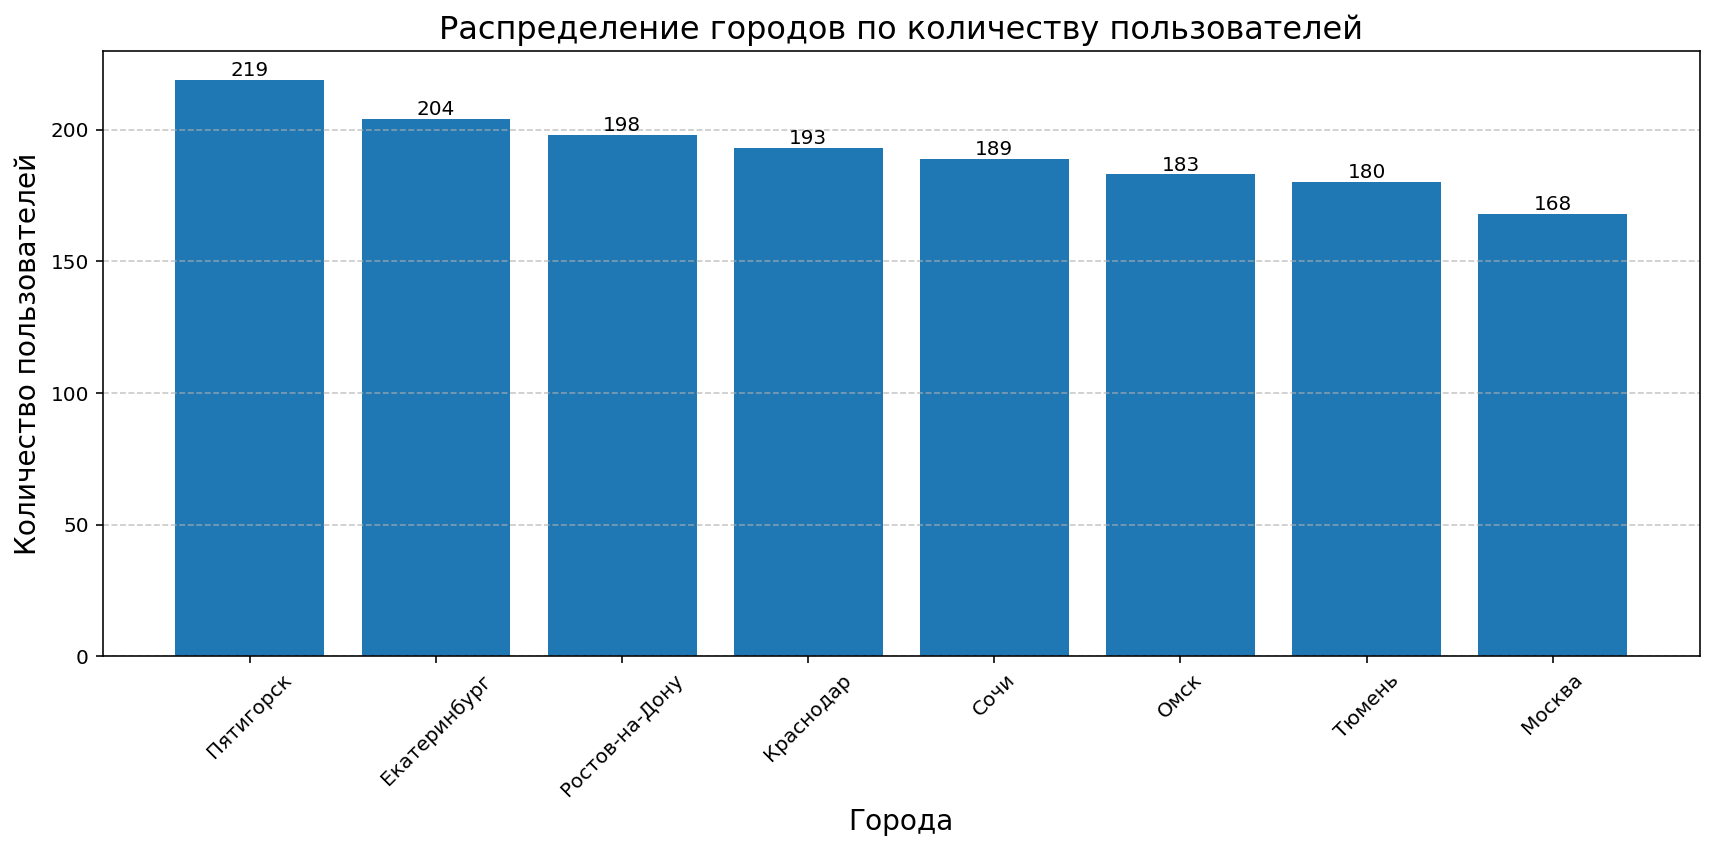

Города по кол-ву пользователей:
-------------------------------


Пятигорск         219
Екатеринбург      204
Ростов-на-Дону    198
Краснодар         193
Сочи              189
Омск              183
Тюмень            180
Москва            168
Name: city, dtype: int64

In [10]:
# Подсчёт количества пользователей в каждом городе
city_counts = user_data['city'].value_counts()

# Построение столбчатой диаграммы
plt.figure(figsize=(12, 6))
bars = plt.bar(city_counts.index, city_counts.values)

# Подпись столбцов
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, int(yval), ha='center', va='bottom')

# Настройка визуализации
plt.title('Распределение городов по количеству пользователей', fontsize=16)
plt.xlabel('Города', fontsize=14)
plt.ylabel('Количество пользователей', fontsize=14)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Улучшаем качество графика
%config InlineBackend.figure_format = 'retina'

# Вывод на экран графика
plt.tight_layout()
plt.show()

# Вывод переменной top_10_cities
print('Города по кол-ву пользователей:')
print('-' * 31)
city_counts

Можно заметить, что **Пятигорск** и **Екатеринбург**, занявшие первое и второе места по количеству пользователей, соответственно, **имеют чуть больше 200 пользователей** — 219 и 204 человека. На следующих позициях расположены **Ростов-на-Дону**, **Краснодар** и **Сочи**. Интересно, что **Москва**, несмотря на статус столицы, **занимает последнее место** в этом списке. Это может свидетельствовать о высокой конкуренции в мегаполисе, где множество альтернативных сервисов может отвлекать пользователей. 

#### Опиcание и визуализация общей информации о соотношении пользователей с подпиской и без подписки
Подсчитаем количество пользователей с разными типами подписки, визуализируем полученную информацию.

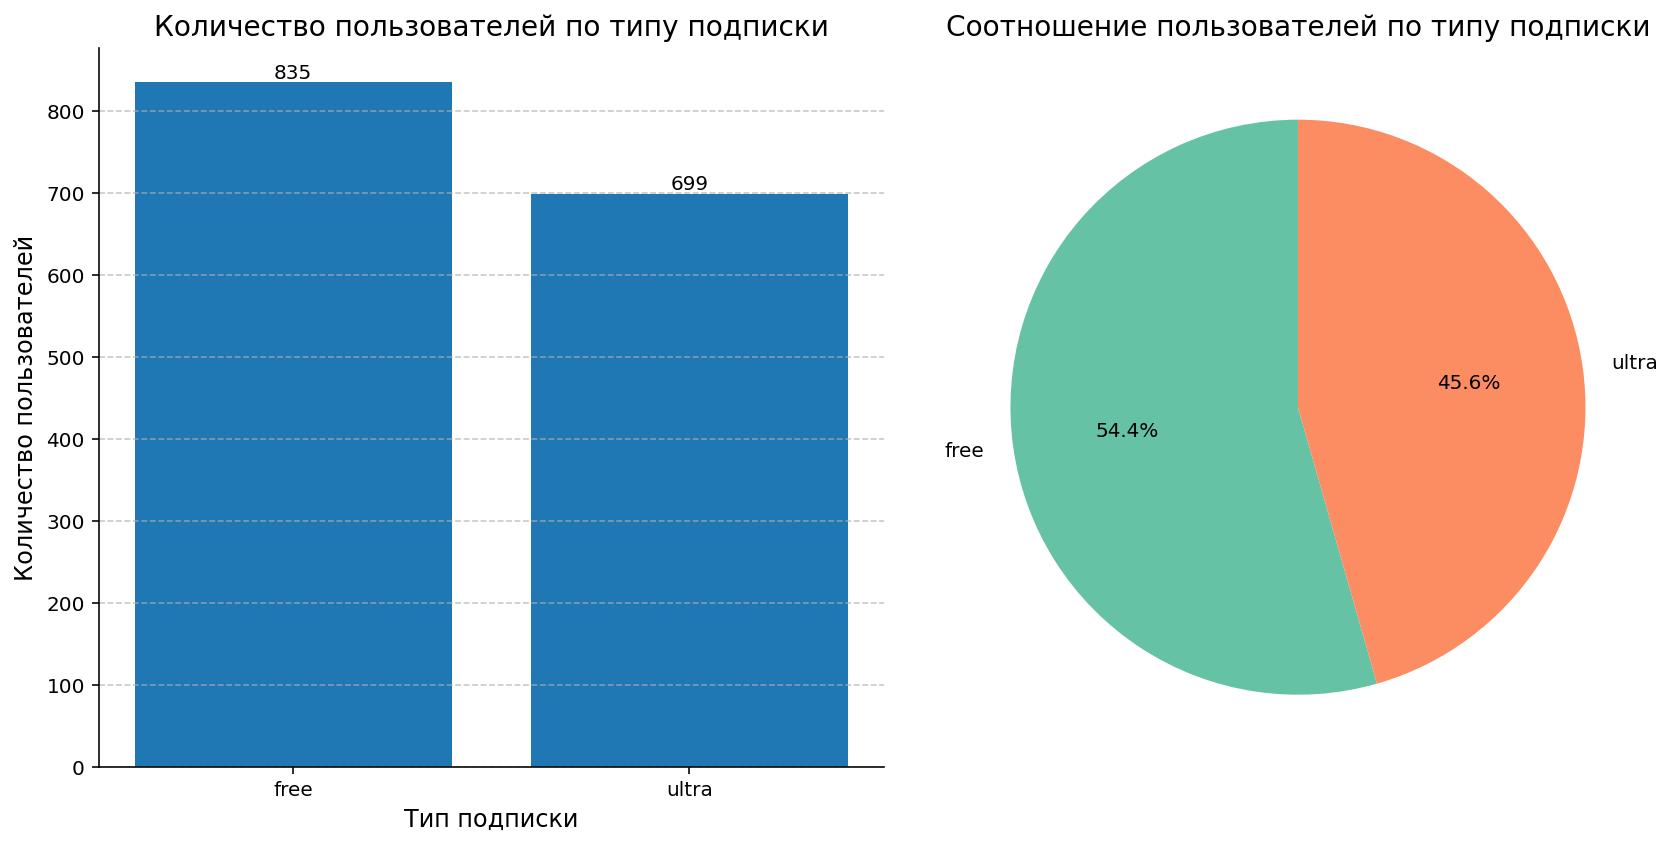

In [11]:
# Подсчёт количества пользователей с разными типами подписки
subscription_counts = user_data['subscription_type'].value_counts()

# Визуализация в виде столбчатой диаграммы
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)  # Разделяем фигуру на 1 строку и 2 колонки, выбираем 1 график
bars = plt.bar(subscription_counts.index, subscription_counts.values)

# Подпись столбцов
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, int(yval), ha='center', va='bottom')

plt.title('Количество пользователей по типу подписки', fontsize=14)
plt.xlabel('Тип подписки', fontsize=12)
plt.ylabel('Количество пользователей', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Убираем рамку вокруг столбчатой диаграммы
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

# Визуализация в виде круговой диаграммы
plt.subplot(1, 2, 2)  # Второй график
plt.pie(subscription_counts, labels=subscription_counts.index, autopct='%1.1f%%', startangle=90, colors=['#66c2a5', '#fc8d62'])
plt.title('Соотношение пользователей по типу подписки', fontsize=14)

# Улучшаем качество графика
%config InlineBackend.figure_format = 'retina'

# Показать графики
plt.tight_layout()
plt.show()

Из полученных графиков видим, что **пользователей без подписки на 8,8% больше, чем пользователей с оформленноой подпиской Ultra. Без подписки катается 835 пользователей, с подпиской - 699**.

#### Опиcание и визуализация общей информации о возрасте пользователей
Выведем еще раз сводную информацию (статистику) по столбцу `user_data['age']`, используя метод `describe` и для лучшей визуализации данных построим гистограмму.

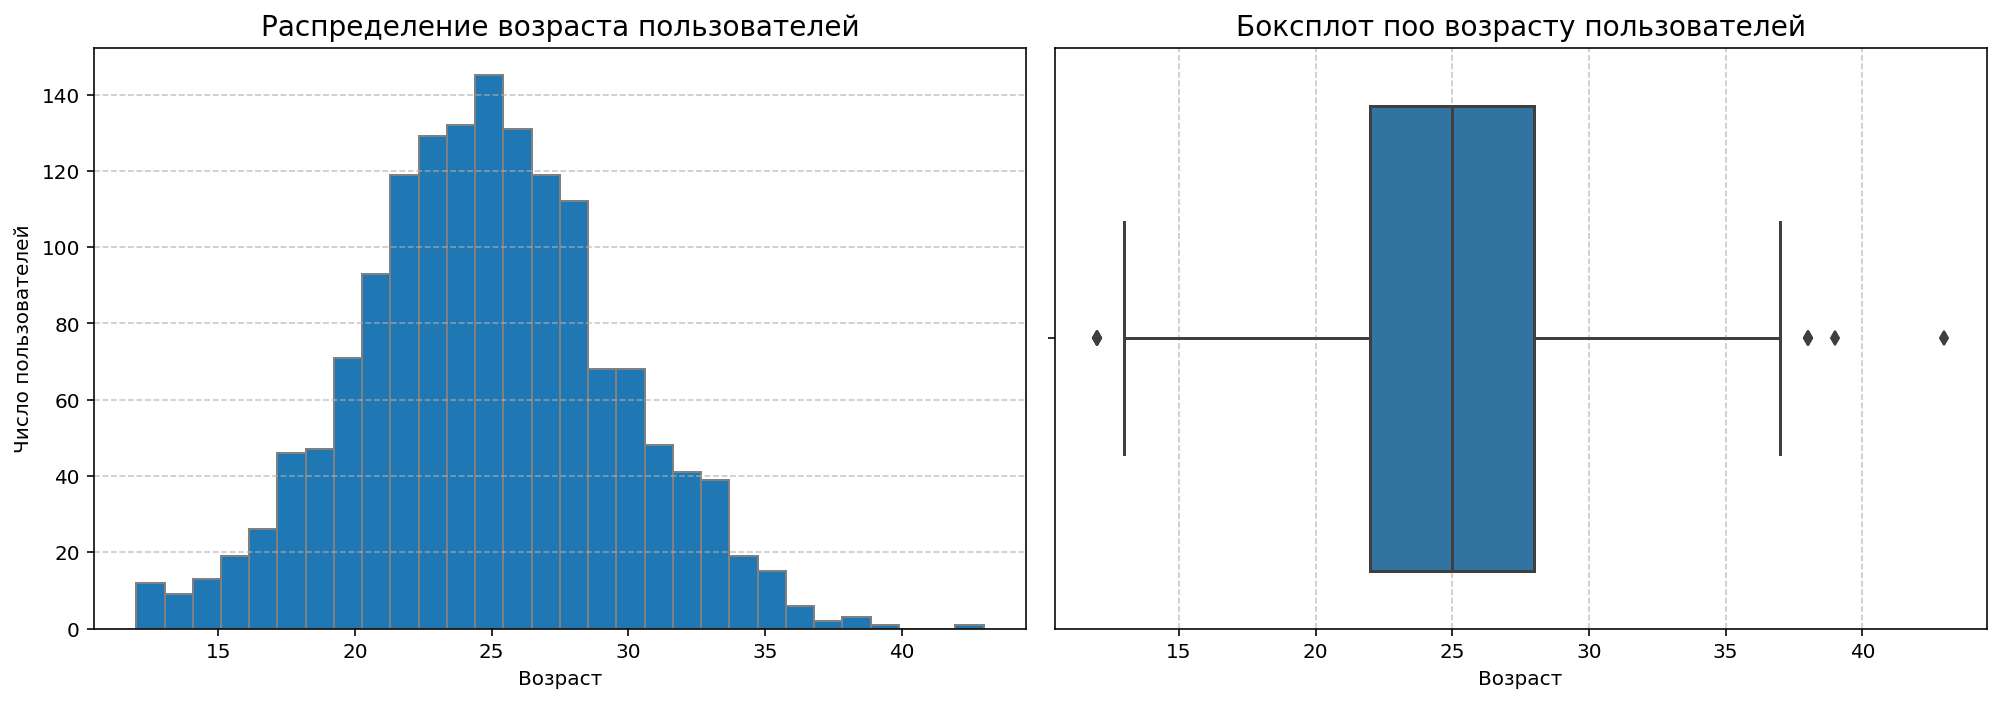

Статистика по числовому столбцу age:
------------------------------------


count    1534.000000
mean       24.903520
std         4.572367
min        12.000000
25%        22.000000
50%        25.000000
75%        28.000000
max        43.000000
Name: age, dtype: float64

In [12]:
# Создаем подграфики
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Построение гистограммы по столбцу 'age'
ax1.hist(user_data['age'], bins=30, edgecolor='grey')
ax1.set_title('Распределение возраста пользователей', fontsize=14)
ax1.set_xlabel('Возраст', fontsize=10)
ax1.set_ylabel('Число пользователей', fontsize=10)
ax1.grid(axis='y', linestyle='--', alpha=0.7)

# Построение боксплота по столбцу 'age'
sns.boxplot(x=user_data['age'], ax=ax2)
ax2.set_title('Боксплот поо возрасту пользователей', fontsize=14)
ax2.set_xlabel('Возраст', fontsize=10)
ax2.grid(axis='x', linestyle='--', alpha=0.7)  # Добавляем сетку к боксплоту

# Улучшаем качество графика
%config InlineBackend.figure_format = 'retina'
plt.tight_layout()
plt.show()

# Статистика по числовому столбцу age
print("Статистика по числовому столбцу age:")
print('-'*36)
display(user_data['age'].describe())


График хорошо показывает, что **выборка имеет нормальное распределение**. **Медианный и средний возраст практически идентичны: `25` и `24.9` лет соответственно**.

#### Опиcание и визуализация общей информации о  расстоянии, которое пользователь преодолел за одну поездку

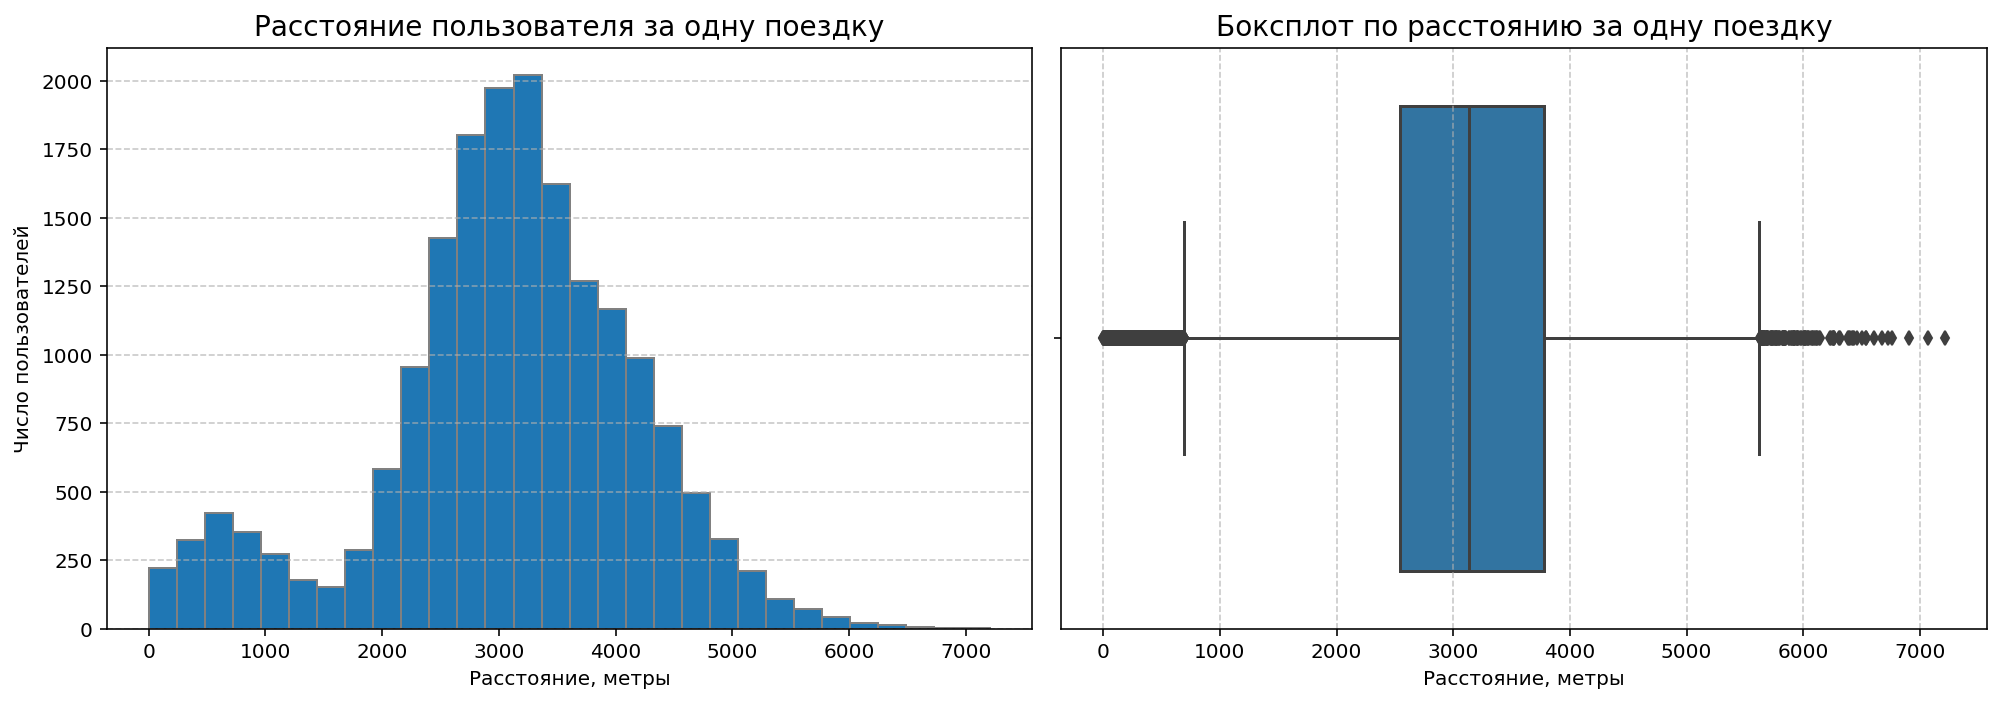

Статистика по числовому столбцу distance:
------------------------------------


count    18068.000000
mean      3070.659976
std       1116.831209
min          0.855683
25%       2543.226360
50%       3133.609994
75%       3776.222735
max       7211.007745
Name: distance, dtype: float64

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Создаем подграфики
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Построение гистограммы по столбцу 'distance'
ax1.hist(scooter_ride_data['distance'], bins=30, edgecolor='grey')
ax1.set_title('Расстояние пользователя за одну поездку', fontsize=14)
ax1.set_xlabel('Расстояние, метры', fontsize=10)
ax1.set_ylabel('Число пользователей', fontsize=10)
ax1.grid(axis='y', linestyle='--', alpha=0.7)

# Построение боксплота по столбцу 'distance'
sns.boxplot(x=scooter_ride_data['distance'], ax=ax2)
ax2.set_title('Боксплот по расстоянию за одну поездку', fontsize=14)
ax2.set_xlabel('Расстояние, метры', fontsize=10)
ax2.grid(axis='x', linestyle='--', alpha=0.7) 

# Улучшаем качество графика
%config InlineBackend.figure_format = 'retina'

# Показать график
plt.tight_layout()
plt.show()

# Статистика по числовому столбцу distance
print("Статистика по числовому столбцу distance:")
print('-'*36)
display(scooter_ride_data['distance'].describe())

Гистограмма имеет форму, напоминающую колокол, что указывает на то, что **распределение может быть близким к нормальному**. Однако **есть и небольшая асимметрия, так как правый хвост длиннее, чем левый - всплеск в районе 500 метров** (опоздание на работу, учебу, подьезд к станции метро, хотя, сеть метро есть только в Москве и Екатеринбурге) 

**Большая часть поездок находится в диапазоне до 4000 метров, с пиком в районе 3000 метров**. Т.е. большинство пользователей предпочитают совершать поездки на средние расстояния, что подтверждает так же **среднее значение, равное 3070.66 метрам, и медиана, равная 3133.61 метрам**.

**Стандартное отклонение составляет 1116.83 метра**, что говорит о том, что существует заметная вариативность в расстояниях.

**Минимальное расстояние составляет 0.86 метра, а максимальное — 7211.01 метров**. Это указывает на то, что есть некоторые поездки на значительно маленькие и большие расстояния, которые могут быть так же и выбросами.Посмотрим на них. 

In [14]:
# Фильтрация данных по условиям
filtered_rides_min = scooter_ride_data[(scooter_ride_data['distance'].between(0, 30))] # от 0 до 30 метров
filtered_rides_max = scooter_ride_data[(scooter_ride_data['distance'].between(6000, 7300))] # от 6000 до 7300 метров

# Выводим результаты
print("Поездки с расстоянием от 0 до 30 метров:")
display(filtered_rides_min.head(10).sort_values(by='distance'))
print("Поездки с расстоянием от 6000 до 7300 метров:")
filtered_rides_max.head(10).sort_values(by='distance')

Поездки с расстоянием от 0 до 30 метров:


,user_id,distance,duration,date,month
11555,1069,0.855683,10.001902,2021-01-31,1
9541,925,2.570787,3.011018,2021-10-19,10
8658,861,6.784447,6.015656,2021-07-21,7
7841,796,7.097072,10.026614,2021-11-26,11
8906,880,11.283615,2.035632,2021-03-28,3
8324,835,12.233115,4.034952,2021-09-19,9
11862,1091,15.630873,13.044660,2021-03-29,3
6691,712,23.963062,2.053251,2021-11-22,11
9784,943,26.784378,5.053569,2021-12-29,12
6611,707,28.793204,14.143966,2021-09-12,9


Поездки с расстоянием от 6000 до 7300 метров:


,user_id,distance,duration,date,month
7185,747,6010.194283,18.025486,2021-03-10,3
7052,738,6059.653105,21.149133,2021-05-02,5
7632,781,6086.437000,26.877662,2021-12-21,12
7617,781,6105.098017,19.210196,2021-01-11,1
7612,780,6112.644835,0.500000,2021-11-23,11
6860,724,6225.520342,0.500000,2021-12-16,12
7830,795,6262.302747,0.500000,2021-09-09,9
7043,737,6386.938020,25.967345,2021-07-31,7
7635,782,6395.396068,28.982735,2021-02-22,2
7913,803,6427.053056,16.854106,2021-01-05,1


Действительно, 0,85 метров за 10 минут, 2,6 метров за 3 минуты или 6262 за 0,5 минут. **Такие данные с большой вероятностью можно отнести к выбросам**, однако, не нужно исключать и варианты каких-либо обстоятельств, случившихся с пользователем. Например, первый раз пользовался самокатом, поэтому очень долго пытался разобраться с системой, не понравилось, решил пойти пешком. Или, например, был снег, пытался поехать, передумал, т.к. скользко, тротуары не чищенные. Поэтому потратил много времени, а далеко не уехал. А вот сбои со временем в 0,5 минут сложно объянить. Тем более, что они повторяются неоднократно. Возможно, сбой системы или при выгрузке данных. **Трогать такие данные не будем, оставим ка есть**. 

#### Опиcание и визуализация общей информации о  продолжительности поездок


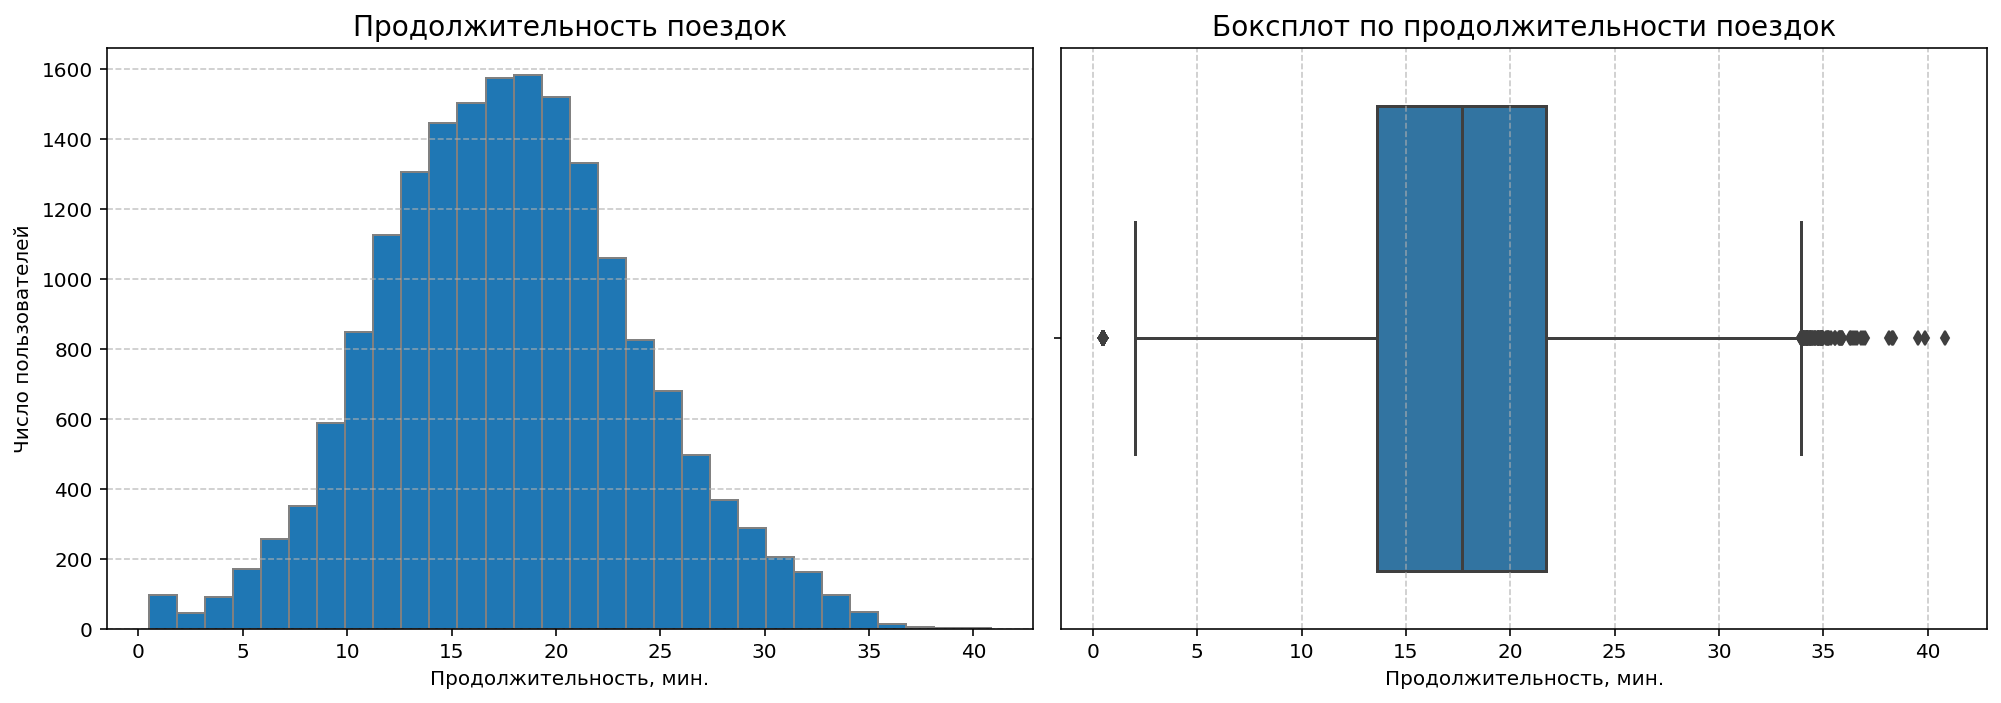

Статистика по числовому столбцу duration:
------------------------------------


count    18068.000000
mean        17.805011
std          6.091051
min          0.500000
25%         13.597563
50%         17.678395
75%         21.724800
max         40.823963
Name: duration, dtype: float64

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# Создаем подграфики
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Построение гистограммы по столбцу 'duration'
ax1.hist(scooter_ride_data['duration'], bins=30, edgecolor='grey')
ax1.set_title('Продолжительность поездок', fontsize=14)
ax1.set_xlabel('Продолжительность, мин.', fontsize=10)
ax1.set_ylabel('Число пользователей', fontsize=10)
ax1.grid(axis='y', linestyle='--', alpha=0.7)

# Построение боксплота по столбцу 'duration'
sns.boxplot(x=scooter_ride_data['duration'], ax=ax2)
ax2.set_title('Боксплот по продолжительности поездок', fontsize=14)
ax2.set_xlabel('Продолжительность, мин.', fontsize=10)
ax2.grid(axis='x', linestyle='--', alpha=0.7) 

# Улучшаем качество графика
%config InlineBackend.figure_format = 'retina'

# Показать график
plt.tight_layout()
plt.show()

# Статистика по числовому столбцу duration
print("Статистика по числовому столбцу duration:")
print('-'*36)
display(scooter_ride_data['duration'].describe())


**Гистограмма имеет нормальное распределение**, хотя можно заметить **небольшую асимметрию с более выраженным левым хвостом**, что говорит о наличии более коротких поездок. **Большая часть поездок находится в диапазоне от 10 до 25 минут, с пиком около 17 минут**. Это говорит о том, что пользователи чаще всего выбирают поездки средней продолжительности.

**Среднее значение практически равно медиане( 17.8 и 17.7 минут соответственно)**, что подтверждает, что половина поездок занимают время в пределах этого значения.

**Стандартное отклонение составляет 6.1 минуты**, что говорит о заметной вариативности в продолжительности поездок.

**Минимальная продолжительность поездки составляет 0.5 минуты, а максимальная — 40.8 минуты**. Это указывает на наличие как очень коротких, так и довольно долгих поездок, что может быть связано с разными сценариями использования самоката, о чем говорилось в предыдущем параграфе, либо с наличием выбросов. 

#### Обобщенный вывод по п.4
1. В текущем анализе указаны данные по **восьми городам**: Екатеринбург, Краснодар, Москва, Омск, Пятигорск, Ростов-на-Дону, Сочи, Тюмень. **Пятигорск и Екатеринбург, занявшие первое и второе места по количеству пользователей, соответственно, имеют чуть больше 200 пользователей — 219 и 204 человека**. На следующих позициях расположились Ростов-на-Дону, Краснодар и Сочи.  **Москва**, несмотря на статус столицы, **занимает последнее место в этом списке**. Это может свидетельствовать о высокой конкуренции в мегаполисе, где множество альтернативных сервисов может отвлекать пользователей.
2. **Пользователей без подписки на 8,8% больше, чем пользователей с оформленноой подпиской Ultra**. Без подписки катается 835 пользователей, с подпиской - 699.
3. При анализе общей информации о возрасте пользователей определено, что **выборка имеет нормальное распределение**. **Медианный и средний возраст практически идентичны: 25 и 24.9 лет соответственно**.
4.  При **анализе и визуализации общей информации о расстоянии, которое пользователь преодолел за одну поездку**, выяснено:
    - **гистограмма имеет форму, напоминающую колокол**, что указывает на то, что **распределение может быть близким к нормальному**. Однако **есть и небольшая асимметрия**, так как правый хвост длиннее, чем левый - всплеск в районе 500 метров (опоздание на работу, учебу, подьезд к станции метро, хотя, сеть метро есть только в Москве и Екатеринбурге);
    - большая часть поездок находится **в диапазоне до 4000 метров**, с **пиком в районе 3000 метров**. Т.е. большинство пользователей предпочитают совершать поездки на средние расстояния, что подтверждает так же **среднее значение**, равное **3070.66 метрам**, и **медиана, равная 3133.61 метрам**;
    - **стандартное отклонение** (std) составляет **1116.83 метра**, что говорит о том, что существует заметная вариативность в расстояниях. Минимальное расстояние составляет **0.86 метра**, а **максимальное — 7211.01 метров**. Это указывает на то, что есть некоторые поездки на значительно маленькие и большие расстояния, которые могут быть так же и выбросами. Трогать такие данные не стали, оставили как есть.
5. При **анализе и визуализации общей информации о продолжительности поездок** определено:
    - **гистограмма имеет нормальное распределение**, хотя можно заметить **небольшую асимметрию с более выраженным левым хвостом**, что говорит о наличии более коротких поездок. **Большая часть поездок находится в диапазоне от 10 до 25 минут, с пиком около 17 минут**. Это говорит о том, что пользователи чаще всего выбирают поездки средней продолжительности;
    - **среднее значение практически равно медиане(17.8 и 17.7 минут соответственно)**, что подтверждает, что половина поездок занимают время в пределах этого значения;
    - **стандартное отклонение составляет 6.1 минуты**, что говорит о заметной вариативности в продолжительности поездок;
    - **минимальная продолжительность поездки составляет 0.5 минуты, а максимальная — 40.8 минуты**. Это указывает на наличие как очень коротких, так и довольно долгих поездок, что может быть связано с разными сценариями использования самоката, о чем говорилось в предыдущем параграфе, либо с наличием выбросов.

### Объединение данных
#### Объединение данных о пользователях, поездках и подписках в один датафрейм
<a id='data_merging'></a>
Объединеним данные о пользователях, поездках и подписках в один датафрейм. Для этого воспользуемся методом `merge()`. 

***Примечание:*** *обязательно нужно осуществить проверку размерности датасетов до объединения (исходников) и после - результирующего датафрейма (с учетом типа объединения - `how='left'`).*

In [16]:
# Проверяем размеры исходных датафреймов
print("Размеры датафрейма с пользователями (user_data):", user_data.shape)
print("Размеры датафрейма с поездками (scooter_ride_data):", scooter_ride_data.shape)
print("Размеры датафрейма с подписками (subscriptions_data):", subscriptions_data.shape)

# Объединяем данные о пользователях с поездками
gofast_merged_data = pd.merge(user_data, scooter_ride_data, on='user_id', how='left')

# Проверяем размер после первого объединения
print("Размер датафрейма после объединения с поездками:", gofast_merged_data.shape)

# Объединяем с данными о подписках
gofast_merged_data = pd.merge(gofast_merged_data, subscriptions_data, on='subscription_type', how='left')

# Выводим размер результирующего датафрейма
print("Размер итогового объединённого датафрейма:", gofast_merged_data.shape)

# Выводим первые строки объединённого датафрейма для проверки
gofast_merged_data.head(5)

Размеры датафрейма с пользователями (user_data): (1534, 5)
Размеры датафрейма с поездками (scooter_ride_data): (18068, 5)
Размеры датафрейма с подписками (subscriptions_data): (2, 4)
Размер датафрейма после объединения с поездками: (18068, 9)
Размер итогового объединённого датафрейма: (18068, 12)


,user_id,name,age,city,subscription_type,distance,duration,date,month,minute_price,start_ride_price,subscription_fee
0,1,Кира,22,Тюмень,ultra,4409.919140,25.599769,2021-01-01,1,6,0,199
1,1,Кира,22,Тюмень,ultra,2617.592153,15.816871,2021-01-18,1,6,0,199
2,1,Кира,22,Тюмень,ultra,754.159807,6.232113,2021-04-20,4,6,0,199
3,1,Кира,22,Тюмень,ultra,2694.783254,18.511000,2021-08-11,8,6,0,199
4,1,Кира,22,Тюмень,ultra,4028.687306,26.265803,2021-08-28,8,6,0,199


Видим, что после объединения пользователей `user_data` с поездками `scooter_ride_data`: (18068, 9) - количество строк совпадает с `scooter_ride_data`, так как объединение происходит по столбцу `user_id` с использованием `how='left'`. Это означает, что все записи из `scooter_ride_data` остались, а данные о пользователях, для которых нет записей в `scooter_ride_data`, будут заполнены `NaN`. 

Тоже самое проиходит и после объединения с подписками: (18068, 12) — количество строк осталось тем же, так как снова использовался `how='left'`. Это означает, что были добавлены столбцы из `subscriptions_data` для пользователей, у которых есть соответствующий тип подписки, а для остальных значений будут `NaN`.

Таким образом, **размеры соответствуют ожиданиям на каждом этапе объединения**.

#### Создание  из датафрейма, созданного на этапе 5.1, ещё двух датафреймов: c данными о пользователях без подписки и с данными о пользователях с подпиской

Создадим ещё два датафрейма из датафрейма `gofast_merged_data`, созданного на этапе 5.1:
- c данными о пользователях **без подписки**;
- с данными о пользователях **с подпиской**.

##### Создание  датафрейма из датафрейма `gofast_merged_data`  c данными о пользователях без подписки

In [17]:
# Фильтруем датафрейм gofast_merged_data, чтобы оставить только пользователей без подписки
users_subscription_free = gofast_merged_data[gofast_merged_data['subscription_type'] == 'free']

# Выводим первые строки нового датафрейма для проверки
print("Данные о пользователях без подписки:")
users_subscription_free.head()

Данные о пользователях без подписки:


,user_id,name,age,city,subscription_type,distance,duration,date,month,minute_price,start_ride_price,subscription_fee
6500,700,Айдар,22,Омск,free,2515.690719,14.944286,2021-01-02,1,8,50,0
6501,700,Айдар,22,Омск,free,846.932642,16.234663,2021-02-01,2,8,50,0
6502,700,Айдар,22,Омск,free,4004.434142,20.016628,2021-02-04,2,8,50,0
6503,700,Айдар,22,Омск,free,1205.911290,9.782872,2021-02-10,2,8,50,0
6504,700,Айдар,22,Омск,free,3047.379435,17.427673,2021-02-14,2,8,50,0


##### Создание  датафрейма из датафрейма `gofast_merged_data`  c данными о пользователях с подпиской

In [18]:
# Фильтруем датафрейм gofast_merged_data, чтобы оставить только пользователей с подпиской
users_subscription_ultra = gofast_merged_data[gofast_merged_data['subscription_type'] == 'ultra']

# Выводим первые строки нового датафрейма для проверки
print("Данные о пользователях с подпиской:")
users_subscription_ultra.head()

Данные о пользователях с подпиской:


,user_id,name,age,city,subscription_type,distance,duration,date,month,minute_price,start_ride_price,subscription_fee
0,1,Кира,22,Тюмень,ultra,4409.919140,25.599769,2021-01-01,1,6,0,199
1,1,Кира,22,Тюмень,ultra,2617.592153,15.816871,2021-01-18,1,6,0,199
2,1,Кира,22,Тюмень,ultra,754.159807,6.232113,2021-04-20,4,6,0,199
3,1,Кира,22,Тюмень,ultra,2694.783254,18.511000,2021-08-11,8,6,0,199
4,1,Кира,22,Тюмень,ultra,4028.687306,26.265803,2021-08-28,8,6,0,199


#### Визуализация информации о расстоянии и времени поездок для пользователей обеих категорий

Визуализируем информацию о расстоянии и времени поездок для пользователей обеих категорий. **Построим гистограммы и боксплоты по данным о расстоянии поездок и времени поездок**.

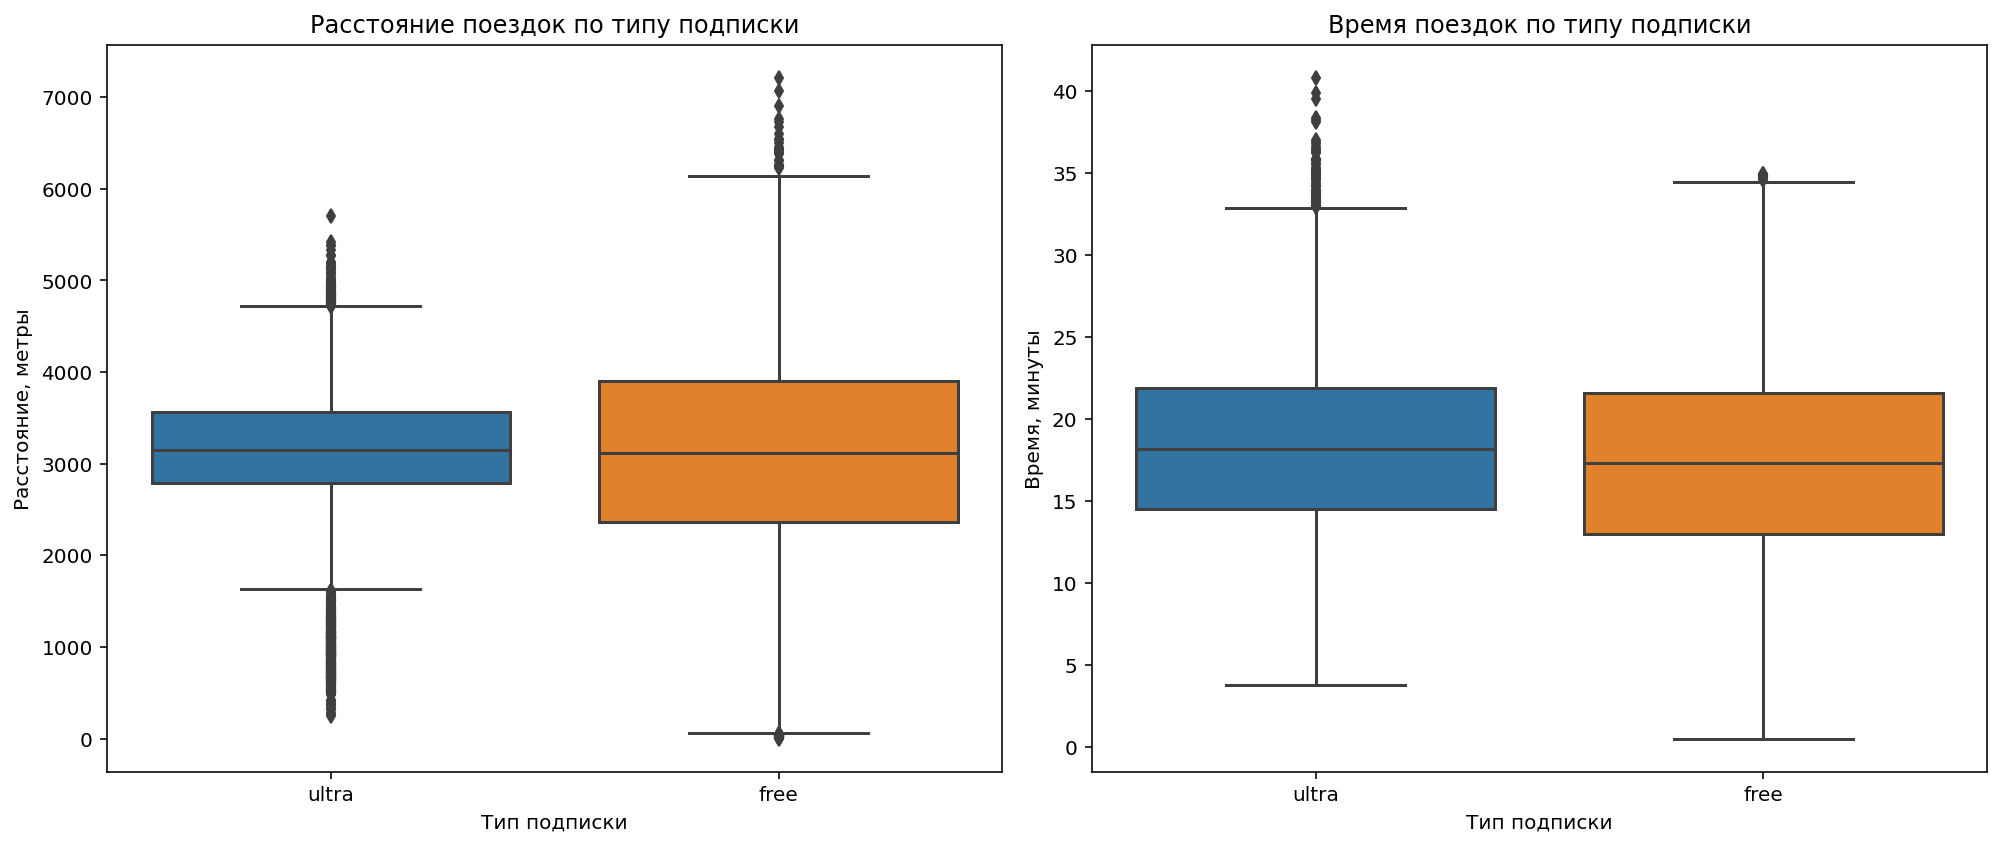

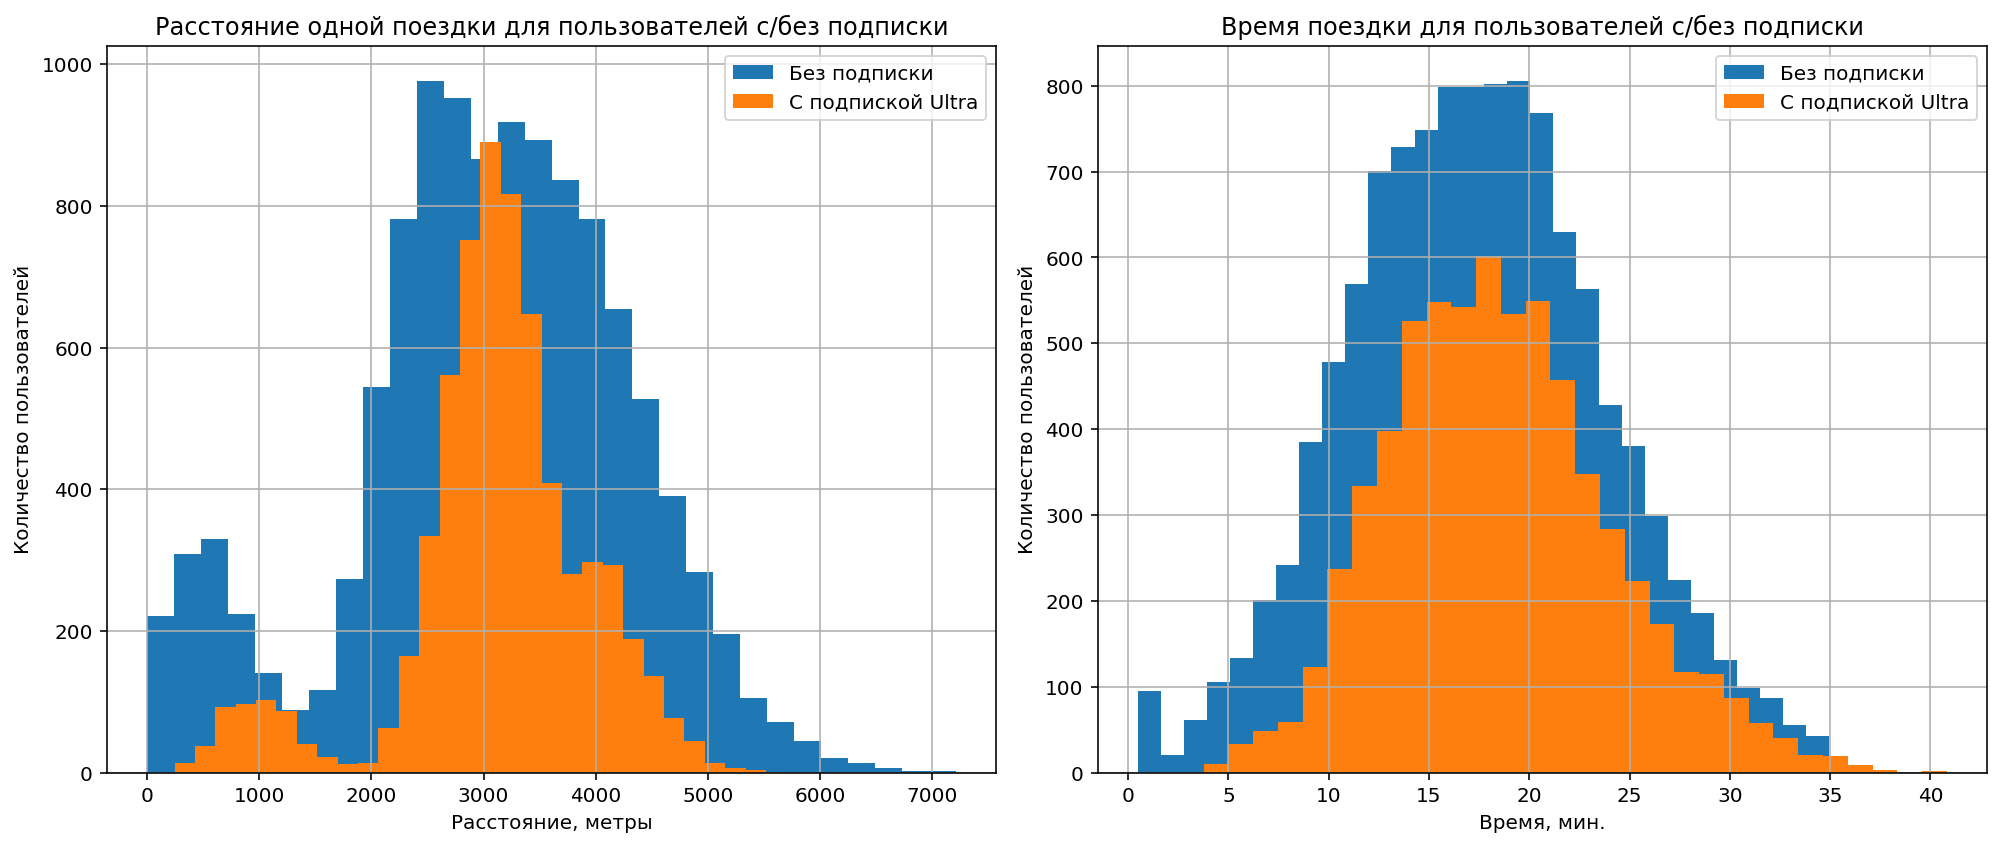

Статистика по столбцам distance и duration по пользователям БЕЗ подписки:
-------------------------------------------------------------------------


,distance,duration
count,11568.000000,11568.000000
mean,3045.495282,17.390909
std,1246.173806,6.326803
min,0.855683,0.500000
25%,2366.562689,12.958437
50%,3114.648465,17.326890
75%,3905.697894,21.594071
max,7211.007745,34.948498


Статистика по столбцам distance и duration  по пользователям С подпиской:
-------------------------------------------------------------------------


,distance,duration
count,6500.000000,6500.000000
mean,3115.445388,18.541985
std,836.895330,5.572048
min,244.210438,3.760353
25%,2785.444017,14.524654
50%,3148.637229,18.178153
75%,3560.574425,21.884129
max,5699.769662,40.823963


In [19]:
# Настройка графиков-боксплотов
plt.figure(figsize=(14, 6))

# График 1: Ящик с усами - Расстояние поездок
plt.subplot(1, 2, 1)
sns.boxplot(x='subscription_type', y='distance', data=gofast_merged_data)
plt.title('Расстояние поездок по типу подписки')
plt.xlabel('Тип подписки')
plt.ylabel('Расстояние, метры')

# График 2: Ящик с усами - Время поездок
plt.subplot(1, 2, 2)
sns.boxplot(x='subscription_type', y='duration', data=gofast_merged_data)
plt.title('Время поездок по типу подписки')
plt.xlabel('Тип подписки')
plt.ylabel('Время, минуты')

# Улучшаем качество графика
%config InlineBackend.figure_format = 'retina'


# Отображение графиков
plt.tight_layout()
plt.show()

# Создание подграфиков-гистограмм
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# График 3: Гистограмма для расстояния поездок
users_subscription_free['distance'].plot(kind='hist', ax=ax1, grid=True, bins=30, alpha=1.0, label='Без подписки')
users_subscription_ultra['distance'].plot(kind='hist', ax=ax1, grid=True, bins=30, alpha=1.0, label='С подпиской Ultra')
ax1.set_title('Расстояние одной поездки для пользователей с/без подписки')
ax1.set_xlabel('Расстояние, метры')
ax1.set_ylabel('Количество пользователей')
ax1.legend(loc='upper right')

# График 4: Гистограмма для времени поездок
users_subscription_free['duration'].plot(kind='hist', ax=ax2, grid=True, bins=30, alpha=1.0, label='Без подписки')
users_subscription_ultra['duration'].plot(kind='hist', ax=ax2, grid=True, bins=30, alpha=1.0, label='С подпиской Ultra')
ax2.set_title('Время поездки для пользователей с/без подписки')
ax2.set_xlabel('Время, мин.')
ax2.set_ylabel('Количество пользователей')
ax2.legend(loc='upper right')

# Улучшаем качество графика
%config InlineBackend.figure_format = 'retina'

# Отображение графиков
plt.tight_layout()
plt.show()

print("Статистика по столбцам distance и duration по пользователям БЕЗ подписки:")
print('-'*73)
display(users_subscription_free[['distance','duration']].describe())

print("Статистика по столбцам distance и duration  по пользователям С подпиской:")
print('-'*73)
display(users_subscription_ultra[['distance','duration']].describe())


На основании представленных визуализаций и статистических данных можно сделать следующие выводы:
- гистограммы показывают, что пользователи без подписки и с подпиской имеют схожие распределения по расстоянию, однако, у подписчиков наблюдается более высокая плотность в среднем диапазоне;
- на боксовых диаграммах видно, что обе категории пользователей имеют схожие медианные значения, однако, в случае подписчиков более узкий интервал между 1 и 3 квартилями, что указывает на более стабильное поведение пользователей с подпиской;
- пользователи с подпиской Ultra имеют среднее расстояние поездки, равное **3115.4 метров**, в то время как пользователи без подписки проезжают в среднем **3045.5 метров**. Это указывает на то, что и подписчики, и не подписчики активно используют сервис и предпочитают более длительные поездки;
 - разброс расстояний для пользователей без подписки (стандартное отклонение **1246.2 метров**) больше, чем у подписчиков (стандартное отклонение **836.9 метров**), что может свидетельствовать о более разнообразном опыте использования для пользователей без подписки;
- средняя продолжительность поездки для пользователей с подпиской составляет **18.5 минут**, а для пользователей без подписки — **17.4 минуты**. Это подтверждает гипотезу о том, что пользователи с подпиской проводят больше времени на поездках;
- стандартное отклонение времени для пользователей без подписки составляет **6.3 минуты**, что также говорит о большем разнообразии времени поездок по сравнению с подписчиками, у которых оно составляет **5.6 минуты**.

Таким образом, можно сделать вывод, что пользователи с подпиской Ultra активно используют сервис и, скорее всего, приносят компании больший доход, благодаря более высоким показателям как по расстоянию, так и по времени поездок.

### Подсчёт выручки
#### Создание датафрейма с агрегированными данными о поездках на основе датафрейма с объединёнными данными из шага 5: поиск суммарного расстояния, количества поездок и суммарного времени для каждого пользователя за каждый месяц
<a id='revenue_calculation'></a>
На основе датафрейма с объединёнными данными из шага 5.1 создадим датафрейм `aggregated_data` с агрегированными данными о поездках и найдем суммарное расстояние, количество поездок и суммарное время для каждого пользователя за каждый месяц. 

Т.к. в следующем пункте будет необходимо в каждой строке исходного датафрейма округлить до следующего целого числа продолжительность каждой поездки для подсчёта стоимости, сделаем это сразу перед созданием нового датафрейма с агрегированными данными.

In [20]:
# Округляем продолжительность каждой поездки в исходном датафрейме до следующего целого числа
gofast_merged_data['duration'] = np.ceil(gofast_merged_data['duration']).astype('int')

# Группируем по user_id и month, а затем аггрегируем данные
aggregated_data = gofast_merged_data.groupby(['user_id', 'month']).agg(
    total_distance=('distance', 'sum'),         # Суммарное расстояние
    total_rides=('distance', 'count'),          # Количество поездок
    total_duration=('duration', 'sum')          # Суммарное время
).reset_index()

# Сортировка по user_id и затем по month
aggregated_data = aggregated_data.sort_values(by=['user_id', 'month']).reset_index(drop=True)

# Выводим получившийся датафрейм
aggregated_data.head(10)

,user_id,month,total_distance,total_rides,total_duration
0,1,1,7027.511294,2,42
1,1,4,754.159807,1,7
2,1,8,6723.470560,2,46
3,1,10,5809.911100,2,32
4,1,11,7003.499363,3,56
5,1,12,6751.629942,2,28
6,2,3,10187.723006,3,63
7,2,4,6164.381824,2,40
8,2,6,3255.338202,1,14
9,2,7,6780.722964,2,48


Перед тем, как начать рассчитывать выручку, **осуществим проверку полученной сводной таблицы `aggregated_data` на наличие пропусков**:

In [21]:
# Проверка на наличие пропусков в сводной таблице aggregated_data
missing_values = aggregated_data.isnull().sum()

# Вывод информации о пропусках
if missing_values.any():
    print("Пропуски в сводной таблице:")
    print(missing_values[missing_values > 0])
else:
    print("Пропусков в сводной таблице нет.")

missing_values

Пропусков в сводной таблице нет.


user_id           0
month             0
total_distance    0
total_rides       0
total_duration    0
dtype: int64

**Пропусков в сводной таблице `aggregated_data` нет**. 

Таким образом, нами **создан новый датафрейм `aggregated_data`** с агрегированными данными о поездках, так же найдены:
- **суммарное расстояние** - столбец `total_distance`,
- **количество поездок** - столбец `total_rides`,
- **суммарное время** - столбец `total_duration`

**для каждого пользователя за каждый месяц**.

#### Добавление в датафрейм `aggregated_data` столбца с помесячной выручкой, которую принёс каждый пользователь

В созданный в п.6.1 датафрейм `aggregated_data` добавим столбец с помесячной выручкой, которую принёс каждый пользователь. Для этого обратимся к информации об условиях оплаты для подписчиков и тех, у кого нет подписки. Продолжительность каждой поездки в каждой строке исходного датафрейма для подсчёта стоимости будем округлять до следующего целого числа: например, значения 25.3, 25.5 и 26.0 будут преобразованы к 26.

In [22]:
# Присоединяем информацию о пользователях из user_data к aggregated_data
aggregated_data = aggregated_data.merge(user_data, how='left', on='user_id')

# Присоединяем информацию о подписках из subscriptions_data к aggregated_data
aggregated_data = aggregated_data.merge(subscriptions_data, how='left', on='subscription_type')

# Добавляем столбец с помесячной выручкой, которую принёс каждый пользователь
def calculate_revenue(row):
    # Вычисляем выручку
    revenue = (row['start_ride_price']*row['total_rides'] +  # Стоимость старта поездки * количество поездок
                row['minute_price'] * row['total_duration'] +  # Стоимость по времени
                (row['subscription_fee'] if row['subscription_type'] == 'ultra' else 0)  # Подписка Ultra
                )
    return revenue

# Применяем функцию к датафрейму для расчета выручки
aggregated_data['revenue'] = aggregated_data.apply(calculate_revenue, axis=1)

# Выводим нужные столбцы
display(aggregated_data[['user_id', 'name', 'age','month', 'revenue', 'city', 'subscription_type']].head(10))

,user_id,name,age,month,revenue,city,subscription_type
0,1,Кира,22,1,451,Тюмень,ultra
1,1,Кира,22,4,241,Тюмень,ultra
2,1,Кира,22,8,475,Тюмень,ultra
3,1,Кира,22,10,391,Тюмень,ultra
4,1,Кира,22,11,535,Тюмень,ultra
5,1,Кира,22,12,367,Тюмень,ultra
6,2,Станислав,31,3,577,Омск,ultra
7,2,Станислав,31,4,439,Омск,ultra
8,2,Станислав,31,6,283,Омск,ultra
9,2,Станислав,31,7,487,Омск,ultra


Итак, **после присоединения к датафрейму `aggregated_data` с агрегированными данными о поездках информации о пользователях и подписках, была посчитана помесячная выручка по каждому пользователю. Продолжительность каждой поездки предварительно была округлена до следующего целого числа.**

### Проверка гипотез
<a id='hypothesis_testing'></a>
Продакт-менеджеры сервиса хотят увеличить количество пользователей с подпиской. Для этого они будут проводить различные акции, но сначала нужно выяснить несколько важных моментов.

#### Проверка гипотезы: тратят ли пользователи с подпиской больше времени на поездки?

Необходимо понять, тратят ли пользователи с подпиской больше времени на поездки? Если да, то пользователи с подпиской могут быть «выгоднее» для компании. Проверим гипотезу. Использованы будут исходные данные о продолжительности каждой сессии — отдельно для подписчиков и тех, у кого нет подписки.

- `Нулевая гипотеза (Но)` - пользователи тратят одинаково времени на поездки, не зависимо от наличия подписки;
- `Альернативная гипотеза (Н1)` - пользователи с подпиской тратят больше времени на поездки;
- `Тип гипотезы (H1)`: правостороння (в тесте используем параметр 'greater');
- Будет проведен односторонний тест с двумя выборками.

In [23]:
alpha = 0.05 # уровень статистической значимости
# если p-value окажется меньше него, отвергнем гипотезу

# При проведении одностороннего теста вправо указваем параметр 'greater'
results = st.ttest_ind(users_subscription_ultra['duration'], users_subscription_free['duration'], alternative='greater')

print('p-значение:', results.pvalue)

if results.pvalue < alpha:
    print('Отвергаем нулевую гипотезу')
else:
    print("Не получилось отвергнуть нулевую гипотезу: нет значительной разницы в времени поездок.") 
    
# Проверяем результаты теста
print('-' * 62)
print('Среднее время поездки пользователей c подпиской Ultra:', round(users_subscription_ultra['duration'].mean(),2))
print('Среднее время поездки пользователей без подписки:', round(users_subscription_free['duration'].mean(),2))  

p-значение: 1.2804098316645618e-34
Отвергаем нулевую гипотезу
--------------------------------------------------------------
Среднее время поездки пользователей c подпиской Ultra: 18.54
Среднее время поездки пользователей без подписки: 17.39


Полученное значение **p-value значительно меньше установленного уровня статистической значимости alpha**, это дает основание **отвергнуть нулевую нипотезу** и сделать вывод, что есть достаточно оснований утверждать, что **пользователи с подпиской действительно тратят больше времени на поездки по сравнению с пользователями без подписки и могут быть более "выгоднее" для компании**. 

Проверка так же подвертила полученный результат теста: среднее время поездки пользователей **c подпиской Ultra**: `18.54 мин.`, среднее время поездки пользователей **без подписки**: `17.39 мин.` 

#### Проверка гипотезы: среднее расстояние, которое проезжают пользователи с подпиской за одну поездку, не превышает 3130 метров

Расстояние одной поездки в 3130 метров — оптимальное с точки зрения износа самоката. Можно ли сказать, что среднее расстояние, которое проезжают пользователи с подпиской за одну поездку, не превышает 3130 метров? Проверим гипотезу и сделаем выводы.


- `Нулевая гипотеза (Но)` - среднее расстояние, которое проезжают пользователи с подпиской за одну поездку, **равно 3130 метров**;
- `Альернативная гипотеза (Н1)` - среднее расстояние, которое проезжают пользователи с подпиской за одну поездку, **больше 3130 метров**;
- `Тип гипотезы (H1)`: правосторонняя (в тесте используем параметр `greater`);
- Будет проведен односторонний тест с одной выборкой.

In [24]:
alpha = 0.05 # уровень статистической значимости
# если p-value окажется меньше него, отвергнем гипотезу

average_distance_subscription = 3130

# При проведении одностороннего теста вправо указваем параметр 'greater'
results = st.ttest_1samp(users_subscription_ultra['distance'], average_distance_subscription, alternative='greater')

print('p-значение:', results.pvalue)

if results.pvalue < alpha:
    print('Отвергаем нулевую гипотезу')
else:
    print("Не получилось отвергнуть нулевую гипотезу: нет значительной разницы в расстоянии поездок") 
    
# Проверяем результаты теста
print('-' * 88)
print('Среднее расстояние, которое проезжают пользователи c подпиской Ultra:', round(users_subscription_ultra['distance'].mean(),2)) 

p-значение: 0.9195368847849785
Не получилось отвергнуть нулевую гипотезу: нет значительной разницы в расстоянии поездок
----------------------------------------------------------------------------------------
Среднее расстояние, которое проезжают пользователи c подпиской Ultra: 3115.45


**Нулевая гипотеза** о том, что среднее расстояние, которое проезжают пользователи с подпиской Ultra за одну поездку, равно 3130 метров, **не была отвергнута**. p-value составило `0.92`, что намного больше установленного уровня значимости `0.05`. Это значит, что разница между средним расстоянием поездок пользователей с подпиской и пороговым значением в 3130 метров не является статистически значимой.

**Среднее расстояние поездок пользователей с подпиской Ultra составляет около 3115.45 метров**. Это показывает, что пользователи не превышают оптимальное расстояние, но разница незначительна с точки зрения статистического анализа. В итоге, можно сказать, что среднее расстояние поездок не превышает 3130 метров.

#### Проверка гипотезы: будет ли помесячная выручка от пользователей с подпиской по месяцам выше, чем выручка от пользователей без подписки

Проверим гипотезу о том, будет ли помесячная выручка от пользователей с подпиской по месяцам выше, чем выручка от пользователей без подписки.

- `Нулевая гипотеза (Но)` - помесячная выручка от пользователей с подпиской равна помесячной выручке пользователей без подписки;
- `Альернативная гипотеза (Н1)` - помесячная выручка от пользователей с подпиской выше помесячной выручке пользователей без подписки;
- `Тип гипотезы (H1)`: правосторонняя (в тесте используем параметр `greater`).

In [25]:
# Сформируем две выборки, в которых будет представлена помесячная выручка 
aggregated_data_ultra = aggregated_data.query("subscription_type == 'ultra'") # от пользователей с подпиской
aggregated_data_free = aggregated_data.query("subscription_type == 'free'") #от пользователей без подписки

alpha = 0.05 # уровень статистической значимости
# если p-value окажется меньше него, отвергнем гипотезу

results = st.ttest_ind(aggregated_data_ultra['revenue'], aggregated_data_free['revenue'], alternative='greater')

print('p-значение:', results.pvalue)

if results.pvalue < alpha:
    print('Отвергаем нулевую гипотезу')
else:
    print('Не получилось отвергнуть нулевую гипотезу')
    
# Проверяем результаты теста
print('-' * 67)
print('Средняя помесячная выручка от пользователей С подпиской, руб.:', round(aggregated_data_ultra['revenue'].mean()))
print('Средняя помесячная выручка от пользователей БЕЗ подписки, руб.:', round(aggregated_data_free['revenue'].mean()))
print('Разница, руб.:', round(aggregated_data_ultra['revenue'].mean() - aggregated_data_free['revenue'].mean()))

p-значение: 1.8850394384715216e-31
Отвергаем нулевую гипотезу
-------------------------------------------------------------------
Средняя помесячная выручка от пользователей С подпиской, руб.: 363
Средняя помесячная выручка от пользователей БЕЗ подписки, руб.: 329
Разница, руб.: 34


Проведенный тест показал, что p-значение значительно ниже уровня статистической значимости в 0.05. Это позволяет **отвергнуть нулевую гипотезу о равенстве помесячной выручки от пользователей с подпиской и без подписки**. Таким образом, можно сделать вывод, что **помесячная выручка от пользователей с подпиской выше, чем у пользователей без подписки**.

#### Ответ на вопрос: Какой тест понадобился бы для проверки гипотезы?

**Вопрос:** `Представьте такую ситуацию: техническая команда сервиса обновила сервера, с которыми взаимодействует мобильное приложение. Она надеется, что из-за этого количество обращений в техподдержку значимо снизилось. Некоторый файл содержит для каждого пользователя данные о количестве обращений до обновления и после него. Какой тест вам понадобился бы для проверки этой гипотезы?`

**Ответ:** В данном случае мы анализировали бы одну генеральную совокупность, с которой произошли некоторые изменения (количество обращений в техподдержку до и после обновления сервера). Т.е. необходимо проверить, равны ли средние совокупности до и после этого изменения. Выборки в этом случае будут зависимыми или парными. 

Чтобы проверить гипотезу о равенстве среднего генеральной совокупности для зависимых (парных) выборок в Python, применяется метод `scipy.stats.ttest_rel()`.

#### Обобщенный вывод по п.7
1. Проверка гипотезы "`Тратят ли пользователи с подпиской больше времени на поездки?`" продемонстрировала:
    - Полученное значение **p-value значительно меньше установленного уровня статистической значимости alpha**, это дает основание **отвергнуть нулевую нипотезу** и сделать вывод, что есть достаточно оснований утверждать, что **пользователи с подпиской действительно тратят больше времени на поездки по сравнению с пользователями без подписки и могут быть более "выгоднее" для компании**.
    - Проверка так же подвертила полученный результат теста: среднее время поездки пользователей **c подпиской Ultra**: `18.54 мин.`, среднее время поездки пользователей **без подписки**: `17.39 мин.` 
2. Проверка гипотезы: "`Среднее расстояние, которое проезжают пользователи с подпиской за одну поездку, не превышает 3130 метров`" показала:
    - **Нулевая гипотеза** о том, что среднее расстояние, которое проезжают пользователи с подпиской Ultra за одну поездку, равно 3130 метров, **не была отвергнута**. p-value составило 0.0805, что больше установленного уровня значимости 0.05. Это значит, что разница между средним расстоянием поездок пользователей с подпиской и пороговым значением в 3130 метров не является статистически значимой.
    - **Среднее расстояние поездок пользователей с подпиской Ultra составляет около 3115.45 метров**. Это показывает, что пользователи не превышают оптимальное расстояние, но разница незначительна с точки зрения статистического анализа. В итоге, можно сказать, что среднее расстояние поездок не превышает 3130 метров.
3. Проверка гипотезы: "`Будет ли помесячная выручка от пользователей с подпиской по месяцам выше, чем выручка от пользователей без подписки`" установила:
    - Проведенный тест показал, что p-значение значительно ниже уровня статистической значимости в 0.05. Это позволяет **отвергнуть нулевую гипотезу о равенстве помесячной выручки от пользователей с подпиской и без подписки**. Таким образом, можно сделать вывод, что **помесячная выручка от пользователей с подпиской выше, чем у пользователей без подписки**.
4. Ответ на вопрос: "`Какой тест понадобился бы для проверки гипотезы?`" следующий:
     - Чтобы проверить гипотезу о равенстве среднего генеральной совокупности для зависимых (парных) выборок в Python, применяется метод `scipy.stats.ttest_rel()`.

### Распределения (необязательное задание)
#### Определение минимального количества промокодов, которое нужно разослать, чтобы вероятность не выполнить план была примерно 5 %
<a id='distributions'></a>
Отделу маркетинга GoFast поставили задачу: нужно провести акцию с раздачей промокодов на один бесплатный месяц подписки, в рамках которой как минимум **`100` существующих клиентов должны продлить эту подписку**. То есть по завершении периода действия подписки пользователь может либо отказаться от неё, либо продлить, совершив соответствующий платёж. 

Эта акция уже проводилась ранее и по итогу выяснилось, что после бесплатного пробного периода **подписку продлевают `10 %`** пользователей. Необходимо выяснить, **какое минимальное количество промокодов нужно разослать, чтобы вероятность не выполнить план была примерно `5 %`.** Подберите параметры распределения, описывающего эту ситуацию, постройте график распределения и сформулируйте ответ на вопрос о количестве промокодов.

Построим для начала **график биномиального распределения**, который описывает указанную ситуацию.

<BarContainer object of 1001 artists>

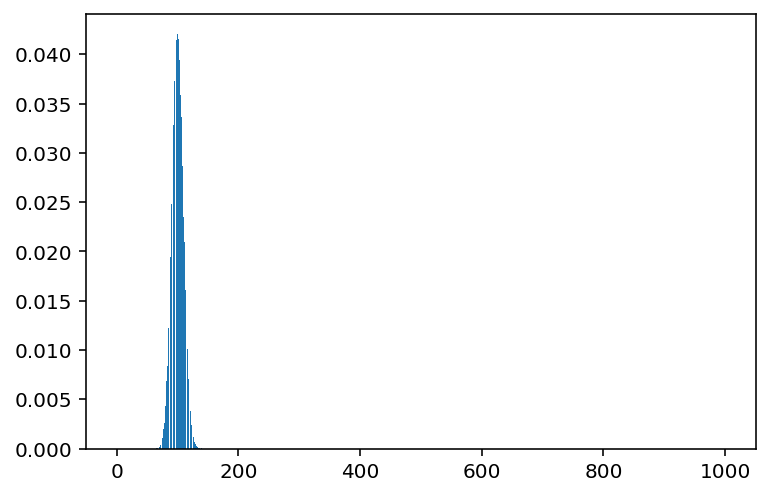

In [26]:
# Параметры
p = 0.1  # Вероятность продления
n = 1000   # Количество разосланных промокодов

distr = []

for k in range(0, n + 1):
    choose = factorial(n) / (factorial(k) * factorial(n - k))
    prob = choose * p**k * (1 - p)**(n - k) 
    distr.append(prob)
    
plt.bar(range(0, n + 1), distr)

График показывает, что при вероятности успеха `p`, равной `10%` и `1000` рассылок, вероятность, что случится невыполнение плана примерно 5 %, крайне мала. Следовательно, подходящие значения для параметра `n` следует определить как: `n-500` и `n+500`.

In [27]:
for n in range(500, 1500):  # Проверяем количество промокодов от 500 до 1500
    # Вычисляем вероятность, что менее 100 клиентов продлят подписку
    if binom.cdf(99, n, p) < 0.05: 
        print("Минимальное количество промокодов для достижения цели:", n)  # Выводим значение
        break  # Выходим из цикла

Минимальное количество промокодов для достижения цели: 1161


Таким образом, **отделу маркетинга GoFast нужно разослать менее `1161 промокодов`, чтобы вероятность не выполнить план была примерно `5 %`.**

#### Построение с помощью аппроксимации примерного графика распределения и оценка вероятности того, что уведомление откроют не более 399,5 тыс. пользователей

Отдел маркетинга рассылает клиентам push-уведомления в мобильном приложении. Клиенты могут открыть его или не открывать. Известно, что **уведомления открывают около 40 % получивших клиентов**. Отдел планирует разослать **1 млн уведомлений**. С помощью аппроксимации постройте примерный график распределения и оцените вероятность того, что уведомление откроют **не более 399,5 тыс. пользователей**.

Аппроксимируем биномиальное распределение нормальным и посчитаем:

In [28]:
# задаём параметры биномиального распределения
n = 1000000
p = 0.4

# зададим мат.ожидание и ст.отклонение нормального распределения равными
# мат.ожиданию и ст.отклонению биномиального распределения
mu = n * p
sigma = sqrt(n * p * (1 - p))

# задаём нормальное распределение
distr = st.norm(mu, sigma) 

# считаем вероятность хвоста слева от 43 тысяч
result = distr.cdf(399500)
print('Вероятность, что при 1 млн. разосланных push-уведомлений откроют не более 399,5 тыс. пользователей:', round(result,2))

Вероятность, что при 1 млн. разосланных push-уведомлений откроют не более 399,5 тыс. пользователей: 0.15


Следовательно,**вероятность того, что при `1 млн.` разосланных push-уведомлений пользователи откроют не более `399,5 тыс.` уведомлений равна `15%`.**

### Общий вывод:
<a id='conclusion'></a>

В рамках настоящего проекта был проведен **детальный анализ данных по выборочным пользователям сервиса аренды самокатов GoFast из нескольких городов, проверены некоторые гипотезы**, которые возможно смогут помочь бизнесу вырасти.

Ниже предоставлен **краткий обзор проведённой работы, сформированы выводы**.

#### Обзор и обработка данных:

Изначально данные были предоставлены в трех датафреймах, **первичный обзор данных показал**:
1. Датайфрейм `user_data (данные о пользователях)`:
- содержит 1565 строк и 5 столбцов;
- наименование столбцов соответствуют стилю `snake_case`;
- все указанные типы данных соответствуют данным, сожержащимся в столбцах;
- пропусков нет;
- минимальный возраст пользователя - 12 лет, максимальный - 43 года, медианный возраст пользователей - 25 лет;
- выявлено 31 явных дубликатов, нужно более детально изучить их;
- в топ городов по количеству пользователей вошли: Пятигорск, Екатеринбург, Ростов-на-Дону, Краснодар, Сочи;
- без подписки 846 пользователей, с подиской - 719 (подписку в мобильном приложении пользователи оформляют на 15% реже)
2. Датайфрейм `scooter_ride_data (данные о поездках)`:
- содержит 18068 строк и 4 столбца;
- наименование столбцов соответствуют стилю `snake_case`;
- столбец `date`, содержащий сведения о дате совершения поездки, имеет тип данных `object` - **нужно перевести его в формат `datetime`**;
- пропусков нет;
- минимальная дистанция - `0,86 метров`, минимальная продолжительность сессии - `0,5 минут`, максимальное расстояние, которое пользователь проехал за одну сессию - `7 211 метров`, максимальная продолжительность сессии - `40,8 минут`;
- явнях дубликатов не выявлено;
- больше всего поездок совершено в январе - декабре 2021 г.
2. Датайфрейм `subscriptions_data (данные о подписках)`:
- содержит 2 строки и 4 столбца;
- наименование столбцов соответствуют стилю `snake_case`;
- все указанные типы данных соответствуют данным, сожержащимся в столбцах;
- пропусков нет;
- стоимость одной минуты поездки варьируется от 6 до 8 руб.;
- явнях дубликатов не выявлено.

#### Предобработка данных:
1. Cтолбец `date` преобразован в формат `datetime`;
2. Создан новый столбец `month` с номером месяца на основе столбца `date`;
3. Дубликаты были обнаружены только в датафрейме `user_data` (31 дубликат). После сортировки по `user_id` стало очевидным, что строки полностью идентичны, данные о пользователях задвоены. Принято решение удалить все дубликаты.

#### Исследовательский анализ данных:

1. Анализировались данные по **восьми городам**: Екатеринбург, Краснодар, Москва, Омск, Пятигорск, Ростов-на-Дону, Сочи, Тюмень. **Пятигорск и Екатеринбург, занявшие первое и второе места по количеству пользователей, соответственно, имеют чуть больше 200 пользователей — 219 и 204 человека**. На следующих позициях расположились Ростов-на-Дону, Краснодар и Сочи.  **Москва**, несмотря на статус столицы, **занимает последнее место в этом списке**. Это может свидетельствовать о высокой конкуренции в мегаполисе, где множество альтернативных сервисов может отвлекать пользователей.
2. **Пользователей без подписки на 8,8% больше, чем пользователей с оформленноой подпиской Ultra**. Без подписки катается 835 пользователей, с подпиской - 699.
3. При анализе общей информации о возрасте пользователей определено, что **выборка имеет нормальное распределение**. **Медианный и средний возраст практически идентичны: 25 и 24.9 лет соответственно**.
4.  При **анализе и визуализации общей информации о расстоянии, которое пользователь преодолел за одну поездку**, выяснено:
    - **гистограмма имеет форму, напоминающую колокол**, что указывает на то, что **распределение может быть близким к нормальному**. Однако **есть и небольшая асимметрия**, так как правый хвост длиннее, чем левый - всплеск в районе 500 метров (опоздание на работу, учебу, подьезд к станции метро, хотя, сеть метро есть только в Москве и Екатеринбурге);
    - большая часть поездок находится **в диапазоне до 4000 метров**, с **пиком в районе 3000 метров**. Т.е. большинство пользователей предпочитают совершать поездки на средние расстояния, что подтверждает так же **среднее значение**, равное **3070.66 метрам**, и **медиана, равная 3133.61 метрам**;
    - **стандартное отклонение** (std) составляет **1116.83 метра**, что говорит о том, что существует заметная вариативность в расстояниях. Минимальное расстояние составляет **0.86 метра**, а **максимальное — 7211.01 метров**. Это указывает на то, что есть некоторые поездки на значительно маленькие и большие расстояния, которые могут быть так же и выбросами. Трогать такие данные не стали, оставили как есть.
5. При **анализе и визуализации общей информации о продолжительности поездок** определено:
    - **гистограмма имеет нормальное распределение**, хотя можно заметить **небольшую асимметрию с более выраженным левым хвостом**, что говорит о наличии более коротких поездок. **Большая часть поездок находится в диапазоне от 10 до 25 минут, с пиком около 17 минут**. Это говорит о том, что пользователи чаще всего выбирают поездки средней продолжительности;
    - **среднее значение практически равно медиане(17.8 и 17.7 минут соответственно)**, что подтверждает, что половина поездок занимают время в пределах этого значения;
    - **стандартное отклонение составляет 6.1 минуты**, что говорит о заметной вариативности в продолжительности поездок;
    - **минимальная продолжительность поездки составляет 0.5 минуты, а максимальная — 40.8 минуты**. Это указывает на наличие как очень коротких, так и довольно долгих поездок, что может быть связано с разными сценариями использования самоката, о чем говорилось в предыдущем параграфе, либо с наличием выбросов.
    
#### Объединение данных
1. Объединенили данные о пользователях, поездках и подписках в один датафрейм `gofast_merged_data`. Для этого использовали метод `merge()`;
2. Создали два датафрейма из датафрейма `gofast_merged_data` c данными о пользователях без подписки и с данными о пользователях с подпиской;
3. По визуализациям:
    - гистограммы показывают, что **пользователи без подписки и с подпиской имеют схожие распределения по расстоянию**, однако, у подписчиков наблюдается более высокая плотность в среднем диапазоне;
    - на боксовых диаграммах видно, что **обе категории пользователей имеют схожие медианные значения**, однако, в случае подписчиков более узкий интервал между 1 и 3 квартилями, что указывает на более стабильное поведение пользователей с подпиской;
    - **пользователи с подпиской Ultra имеют среднее расстояние поездки, равное 3115.4 метров, в то время как пользователи без подписки проезжают в среднем 3045.5 метров**. Это указывает на то, что и подписчики, и не подписчики активно используют сервис и предпочитают более длительные поездки;
    - **разброс расстояний для пользователей без подписки (стандартное отклонение 1246.2 метров) больше, чем у подписчиков (стандартное отклонение 836.9 метров)**, что может свидетельствовать о более разнообразном опыте использования для пользователей без подписки;
    - **средняя продолжительность поездки для пользователей с подпиской составляет 18.5 минут, а для пользователей без подписки — 17.4 минуты**. Это подтверждает гипотезу о том, что пользователи с подпиской проводят больше времени на поездках;
    - **стандартное отклонение времени для пользователей без подписки составляет 6.3 минуты**, что также говорит о большем разнообразии времени поездок по сравнению с подписчиками, у которых оно составляет **5.6 минуты**.
    - можно сделать вывод, что **пользователи с подпиской Ultra активно используют сервис** и, скорее всего, приносят компании больший доход, благодаря более высоким показателям как по расстоянию, так и по времени поездо

#### Подсчет выручки

1. **Cоздан новый датафрейм `aggregated_data`** с агрегированными данными о поездках, так же найдены для каждого пользователя за каждый месяц:
- **суммарное расстояние** - столбец `total_distance`,
- **количество поездок** - столбец `total_rides`,
- **суммарное время** - столбец `total_duration`
2. После присоединения к датафрейму `aggregated_data` информации о пользователях и подписках, была посчитана помесячная выручка по каждому пользователю. Продолжительность каждой поездки предварительно была округлена до следующего целого числа.

#### Проверка гипотез
1. Проверка гипотезы "`Тратят ли пользователи с подпиской больше времени на поездки?`" продемонстрировала:
    - Полученное значение **p-value значительно меньше установленного уровня статистической значимости alpha**, это дает основание **отвергнуть нулевую нипотезу** и сделать вывод, что есть достаточно оснований утверждать, что **пользователи с подпиской действительно тратят больше времени на поездки по сравнению с пользователями без подписки и могут быть более "выгоднее" для компании**.
    - Проверка так же подвертила полученный результат теста: среднее время поездки пользователей **c подпиской Ultra**: `18.54 мин.`, среднее время поездки пользователей **без подписки**: `17.39 мин.` 
2. Проверка гипотезы: "`Среднее расстояние, которое проезжают пользователи с подпиской за одну поездку, не превышает 3130 метров`" показала:
    - **Нулевая гипотеза** о том, что среднее расстояние, которое проезжают пользователи с подпиской Ultra за одну поездку, равно 3130 метров, **не была отвергнута**. p-value составило 0.0805, что больше установленного уровня значимости 0.05. Это значит, что разница между средним расстоянием поездок пользователей с подпиской и пороговым значением в 3130 метров не является статистически значимой.
    - **Среднее расстояние поездок пользователей с подпиской Ultra составляет около 3115.45 метров**. Это показывает, что пользователи не превышают оптимальное расстояние, но разница незначительна с точки зрения статистического анализа. В итоге, можно сказать, что среднее расстояние поездок не превышает 3130 метров.
3. Проверка гипотезы: "`Будет ли помесячная выручка от пользователей с подпиской по месяцам выше, чем выручка от пользователей без подписки`" установила:
    - Проведенный тест показал, что p-значение значительно ниже уровня статистической значимости в 0.05. Это позволяет **отвергнуть нулевую гипотезу о равенстве помесячной выручки от пользователей с подпиской и без подписки**. Таким образом, можно сделать вывод, что **помесячная выручка от пользователей с подпиской выше, чем у пользователей без подписки**.
4. Ответ на вопрос: "`Какой тест понадобился бы для проверки гипотезы?`" следующий:
     - Чтобы проверить гипотезу о равенстве среднего генеральной совокупности для зависимых (парных) выборок в Python, применяется метод `scipy.stats.ttest_rel()`.
     
#### Распределения     
1. Отделу маркетинга GoFast нужно разослать менее 1161 промокодов, чтобы вероятность не выполнить план была примерно 5 %.
2. Вероятность того, что при 1 млн. разосланных push-уведомлений пользователи откроют не более 399,5 тыс. уведомлений равна 15%.

### Рекомендации по развитию аренды самокатов

По результатам исследования хотелось бы предложить **несколько рекомендаций по развитию GoFast аренды самокатов**:

1. Поскольку пользователи с подпиской Ultra тратят больше времени на поездки, можно рассмотреть **возможность запуска акций для привлечения новых подписчиков**. Например, временные скидки на подписку или бесплатные пробные периоды могут повысить интерес к данному варианту.

2. Учитывая, что пользователи с подпиской проезжают около 3115 метров, следует рассмотреть **возможность изменения ценовой политики или структуры тарифов**, чтобы привлечь больше пользователей к подписке. Например, можно предложить пакетные тарифы для регулярных пользователей.

3. Важно **обратить внимание на городские районы с высоким уровнем использования сервиса**. Это может помочь в более целенаправленном размещении самокатов, что повысит доступность и удобство для пользователей.

4. **Разработка программы лояльности для постоянных клиентов** может увеличить удержание пользователей и увеличить выручку. Например, предлагать бонусные поездки или скидки для клиентов, которые регулярно пользуются услугами.

5. На основе анализа продолжительности поездок стоит обратить внимание на среднее время, которое пользователи тратят на поездки. Возможно, **стоит оптимизировать маршрутные подсказки или предлагать более эффективные пути передвижения**.

6. Исходя из данных о максимальной продолжительности поездки (40.8 минут), можно внедрить **дополнительные услуги, такие как аренда самокатов на длительный срок**, что может привлечь новых клиентов, ищущих более экономичные варианты.

Надеемся, что эти рекомендации могут помочь GoFast не только увеличить выручку, но и повысить удовлетворенность пользователей, что в свою очередь может способствовать росту числа клиентов.